# AI Agent vs Human Contributions in Open-Source Development
### Comparative analysis of Pull Requests across 10 major GitHub repositories

**Classification heuristic:** A PR is tagged **agent** if its branch name starts with `agents/`, `copilot/`, `robo/`, or `fix/`, OR if any commit author name/email contains known AI-tool tokens (`copilot`, `[bot]`, `cursor`, `swe-agent`, `gpt`, `claude`, etc.). All others are tagged **human**.


In [ ]:
# ── 1. Imports ──────────────────────────────────────────────────────────────
import json, glob, os
from datetime import datetime, timezone
from statistics import median
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})
print("Imports OK")


Imports OK


In [ ]:
# ── 2. Classification helpers ─────────────────────────────────────────────
BRANCH_AGENT_PREFIXES = ("agents/", "copilot/", "robo/", "fix/")
AUTHOR_AGENT_TOKENS = [
    "copilot", "[bot]", "bot@", "autofix", "swe-agent", "vs-code-engineering",
    "cursor", "cursoragent", "codeium", "tabnine", "claude", "gpt", "openai",
]

def parse_dt(value):
    if not value:
        return None
    try:
        return datetime.fromisoformat(value.replace("Z", "+00:00"))
    except Exception:
        return None

def classify_pr(pr):
    branch = (pr.get("headRefName") or "").lower()
    if branch.startswith(BRANCH_AGENT_PREFIXES):
        return "agent"
    timeline_nodes = pr.get("timelineItems", {}).get("nodes", [])
    authors = []
    for item in timeline_nodes:
        if item.get("__typename") == "PullRequestCommit":
            for a in item.get("commit", {}).get("authors", {}).get("nodes", []):
                authors.append(((a.get("name") or "") + " " + (a.get("email") or "")).lower())
    author_blob = " | ".join(authors)
    if any(tok in author_blob for tok in AUTHOR_AGENT_TOKENS):
        return "agent"
    return "human"

print("Classification logic ready")


Classification logic ready


In [ ]:
# ── 2b. Strict LLM-only classification (excludes generic automation signals) ──
STRICT_BRANCH_AGENT_PREFIXES = ("agents/", "copilot/")  # "fix/" and "robo/" excluded
STRICT_AUTHOR_AGENT_TOKENS = [
    "copilot", "cursor", "cursoragent", "codeium", "tabnine", "claude", "gpt", "openai", "swe-agent",
]

def classify_pr_strict(pr):
    branch = (pr.get("headRefName") or "").lower()
    if branch.startswith(STRICT_BRANCH_AGENT_PREFIXES):
        return "agent"
    timeline_nodes = pr.get("timelineItems", {}).get("nodes", [])
    authors = []
    for item in timeline_nodes:
        if item.get("__typename") == "PullRequestCommit":
            for a in item.get("commit", {}).get("authors", {}).get("nodes", []):
                authors.append(((a.get("name") or "") + " " + (a.get("email") or "")).lower())
    author_blob = " | ".join(authors)
    if any(tok in author_blob for tok in STRICT_AUTHOR_AGENT_TOKENS):
        return "agent"
    return "human"

print("Strict classification logic ready")

Strict classification logic ready


In [ ]:
# ── 2c. Corrected classification: matches main.tex's documented methodology exactly (drops the undocumented "fix/" prefix, keeps every documented author token) ──
CORRECTED_BRANCH_AGENT_PREFIXES = ("agents/", "copilot/")
CORRECTED_AUTHOR_AGENT_TOKENS = AUTHOR_AGENT_TOKENS  # unchanged from Cell 2 -- matches the paper's documented list

def classify_pr_corrected(pr):
    branch = (pr.get("headRefName") or "").lower()
    if branch.startswith(CORRECTED_BRANCH_AGENT_PREFIXES):
        return "agent"
    timeline_nodes = pr.get("timelineItems", {}).get("nodes", [])
    authors = []
    for item in timeline_nodes:
        if item.get("__typename") == "PullRequestCommit":
            for a in item.get("commit", {}).get("authors", {}).get("nodes", []):
                authors.append(((a.get("name") or "") + " " + (a.get("email") or "")).lower())
    author_blob = " | ".join(authors)
    if any(tok in author_blob for tok in CORRECTED_AUTHOR_AGENT_TOKENS):
        return "agent"
    return "human"

print("Corrected classification logic ready")

Corrected classification logic ready


In [ ]:
# ── 3. Load all repository JSON files ────────────────────────────────────
DATA_DIR = "data"
rows = []

for fp in sorted(glob.glob(os.path.join(DATA_DIR, "*.json"))):
    if fp.lower().endswith("desktop.ini"):
        continue
    with open(fp, "r", encoding="utf-8") as f:
        d = json.load(f)
    repo_meta = d.get("repository", {})
    repo_name = repo_meta.get("nameWithOwner",
                              os.path.basename(fp).replace(".json", "").replace("+", "/"))
    prs = repo_meta.get("pullRequests", {}).get("nodes", [])

    for pr in prs:
        tl = pr.get("timelineItems", {}).get("nodes", [])
        commit_count  = sum(1 for n in tl if n.get("__typename") == "PullRequestCommit")
        review_count  = sum(1 for n in tl if n.get("__typename") == "PullRequestReview")
        comment_count = sum(1 for n in tl if n.get("__typename") == "IssueComment")

        created = parse_dt(pr.get("createdAt"))
        closed  = parse_dt(pr.get("closedAt"))
        merged  = parse_dt(pr.get("mergedAt"))
        end     = closed if closed else datetime.now(timezone.utc)
        lifetime_h = (end - created).total_seconds() / 3600 if created else None

        additions  = pr.get("additions",  0) or 0
        deletions  = pr.get("deletions",  0) or 0
        changed    = pr.get("changedFiles", 0) or 0
        total_comm = pr.get("totalCommentsCount", 0) or 0

        rows.append({
            "repo":          repo_name,
            "origin":        classify_pr(pr),
            "origin_strict": classify_pr_strict(pr),
            "origin_corrected": classify_pr_corrected(pr),
            "state":         pr.get("state"),
            "is_merged":     merged is not None,
            "createdAt":     created,
            "additions":     additions,
            "deletions":     deletions,
            "total_churn":   additions + deletions,
            "changedFiles":  changed,
            "totalComments": total_comm,
            "commit_count":  commit_count,
            "review_count":  review_count,
            "lifetime_hours": lifetime_h,
        })

print(f"Loaded {len(rows):,} pull requests across {len(set(r['repo'] for r in rows))} repositories")
agent_n = sum(1 for r in rows if r["origin"] == "agent")
human_n = len(rows) - agent_n
print(f"  Agent PRs : {agent_n:>8,}  ({agent_n*100/len(rows):.1f}%)")
print(f"  Human PRs : {human_n:>8,}  ({human_n*100/len(rows):.1f}%)")


Loaded 198,739 pull requests across 10 repositories
  Agent PRs :   31,400  (15.8%)
  Human PRs :  167,339  (84.2%)


In [ ]:
# ── 3b. Diagnostic: exposure from the undocumented "fix/" branch prefix ──
fix_flagged, fix_branch_only = 0, 0
for fp in sorted(glob.glob(os.path.join(DATA_DIR, "*.json"))):
    if fp.lower().endswith("desktop.ini"):
        continue
    with open(fp, "r", encoding="utf-8") as f:
        d = json.load(f)
    for pr in d.get("repository", {}).get("pullRequests", {}).get("nodes", []):
        branch = (pr.get("headRefName") or "").lower()
        if branch.startswith("fix/"):
            fix_flagged += 1
            timeline_nodes = pr.get("timelineItems", {}).get("nodes", [])
            authors = []
            for item in timeline_nodes:
                if item.get("__typename") == "PullRequestCommit":
                    for a in item.get("commit", {}).get("authors", {}).get("nodes", []):
                        authors.append(((a.get("name") or "") + " " + (a.get("email") or "")).lower())
            author_blob = " | ".join(authors)
            if not any(tok in author_blob for tok in AUTHOR_AGENT_TOKENS):
                fix_branch_only += 1

print(f"PRs with head branch starting 'fix/': {fix_flagged:,}")
print(f"Of those, agent-labeled ONLY because of 'fix/' (no author-token match): {fix_branch_only:,}")

PRs with head branch starting 'fix/': 9,562
Of those, agent-labeled ONLY because of 'fix/' (no author-token match): 8,198


## Section 1 — Overall Summary Statistics


In [ ]:
# ── 4. Overall summary table ──────────────────────────────────────────────
def med(vals):
    clean = [v for v in vals if v is not None]
    return round(median(clean), 2) if clean else None

def pct(part, whole):
    return round(part * 100 / whole, 2) if whole else 0

for origin in ("agent", "human"):
    g = [r for r in rows if r["origin"] == origin]
    merged = sum(1 for r in g if r["is_merged"])
    print(f"\n{'─'*44}")
    print(f"  {origin.upper():6s}  |  {len(g):>7,} PRs")
    print(f"{'─'*44}")
    print(f"  Merged rate          : {pct(merged, len(g)):5.1f}%")
    print(f"  Median churn (lines) : {med([r['total_churn']   for r in g]):>8}")
    print(f"  Median changed files : {med([r['changedFiles']  for r in g]):>8}")
    print(f"  Median lifetime (h)  : {med([r['lifetime_hours'] for r in g]):>8}")
    print(f"  Median commits       : {med([r['commit_count']  for r in g]):>8}")
    print(f"  Median reviews       : {med([r['review_count']  for r in g]):>8}")
    print(f"  Median comments      : {med([r['totalComments'] for r in g]):>8}")



────────────────────────────────────────────
  AGENT   |   31,400 PRs
────────────────────────────────────────────
  Merged rate          :  57.9%
  Median churn (lines) :     44.0
  Median changed files :      2.0
  Median lifetime (h)  :    13.81
  Median commits       :      2.0
  Median reviews       :      1.0
  Median comments      :      3.0

────────────────────────────────────────────
  HUMAN   |  167,339 PRs
────────────────────────────────────────────
  Merged rate          :  75.1%
  Median churn (lines) :       33
  Median changed files :        2
  Median lifetime (h)  :     6.29
  Median commits       :        1
  Median reviews       :        1
  Median comments      :        2


## Section 2 — Per-Repo Breakdown


In [ ]:
# ── 5. Per-repo counts & merge rates ────────────────────────────────────
repos = sorted({r["repo"] for r in rows})

repo_stats = {}
for repo in repos:
    for origin in ("agent", "human"):
        g = [r for r in rows if r["repo"] == repo and r["origin"] == origin]
        merged = sum(1 for r in g if r["is_merged"])
        repo_stats[(repo, origin)] = {
            "n": len(g),
            "merge_rate":    pct(merged, len(g)) if g else 0,
            "med_churn":     med([r["total_churn"]    for r in g]),
            "med_files":     med([r["changedFiles"]   for r in g]),
            "med_lifetime_h": med([r["lifetime_hours"] for r in g]),
        }

print(f"{'Repository':<40} {'Agent PRs':>10} {'Human PRs':>10} {'Agent%':>8} {'Ag Merge%':>10} {'Hu Merge%':>10}")
print("─" * 95)
for repo in repos:
    a = repo_stats[(repo, "agent")]
    h = repo_stats[(repo, "human")]
    total = a["n"] + h["n"]
    print(f"{repo:<40} {a['n']:>10,} {h['n']:>10,} {pct(a['n'],total):>7.1f}% {a['merge_rate']:>9.1f}% {h['merge_rate']:>9.1f}%")


Repository                                Agent PRs  Human PRs   Agent%  Ag Merge%  Hu Merge%
───────────────────────────────────────────────────────────────────────────────────────────────
Genymobile/scrcpy                                15        853     1.7%       0.0%      22.7%
Significant-Gravitas/AutoGPT                  3,201      4,847    39.8%      65.6%      48.1%
TheAlgorithms/Python                          3,614      9,308    28.0%      19.6%      29.1%
ant-design/ant-design                         3,991     18,604    17.7%      64.6%      81.9%
langchain-ai/langchain                        1,734     21,238     7.5%      40.7%      77.0%
microsoft/PowerToys                             492      7,778     6.0%      48.4%      86.4%
microsoft/TypeScript                          1,471     17,988     7.6%      64.2%      78.9%
microsoft/vscode                              6,626     51,441    11.4%      58.8%      85.3%
open-webui/open-webui                         2,156      6

## Section 3 — Charts: Volume, Merge Rates, Code Churn, Lifetime


/tmp/ipykernel_582/743702279.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([short_names[r] for r in repos], rotation=35, ha="right", fontsize=8)


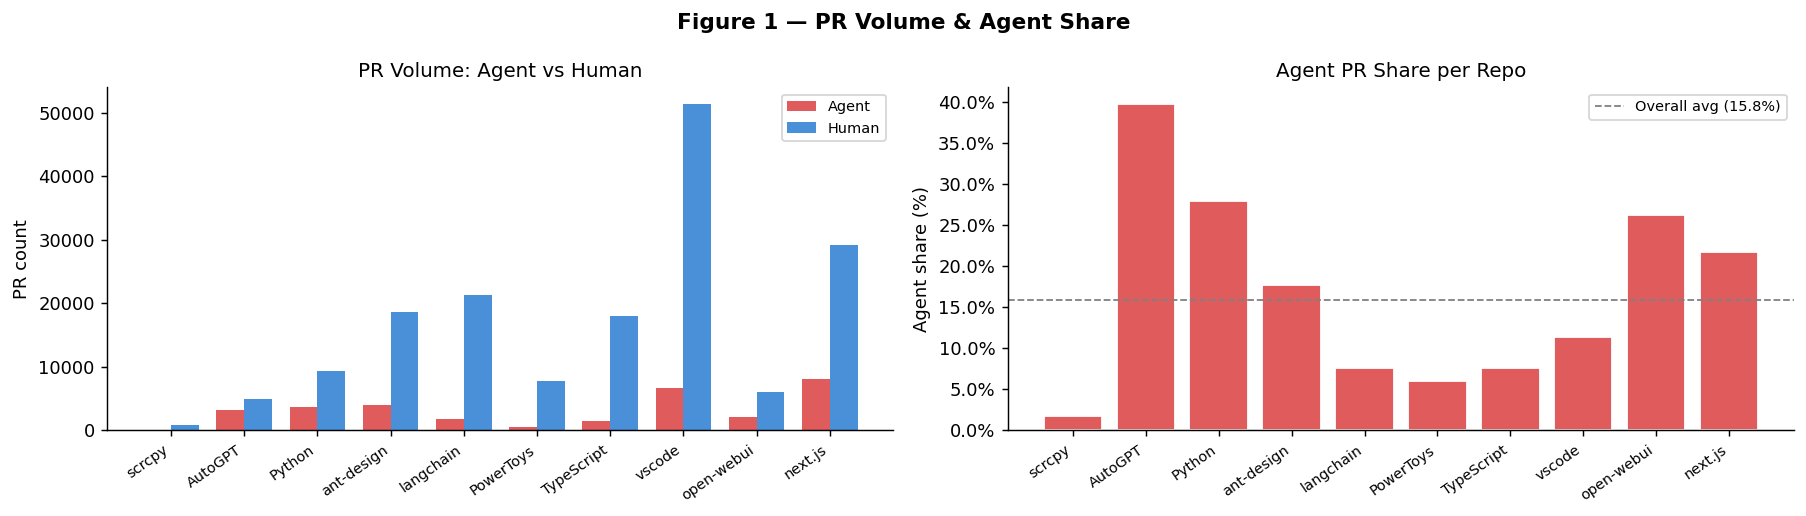

In [ ]:
# ── 6. Chart helpers & Figure 1: Volume + Agent Share ───────────────────
short_names = {r: r.split("/")[1] for r in repos}
COLORS = {"agent": "#E05C5C", "human": "#4A90D9"}
x = np.arange(len(repos))
W = 0.38

def bar_pair(ax, agent_vals, human_vals, ylabel, title, fmt=None):
    ax.bar(x - W/2, agent_vals, W, label="Agent", color=COLORS["agent"])
    ax.bar(x + W/2, human_vals, W, label="Human", color=COLORS["human"])
    ax.set_xticks(x)
    ax.set_xticklabels([short_names[r] for r in repos], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    if fmt == "pct":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

agent_counts = [repo_stats[(r, "agent")]["n"] for r in repos]
human_counts = [repo_stats[(r, "human")]["n"] for r in repos]
bar_pair(axes[0], agent_counts, human_counts, "PR count", "PR Volume: Agent vs Human")

total_counts = [a + h for a, h in zip(agent_counts, human_counts)]
agent_pcts   = [pct(a, t) for a, t in zip(agent_counts, total_counts)]
axes[1].bar([short_names[r] for r in repos], agent_pcts, color=COLORS["agent"], edgecolor="white")
axes[1].axhline(pct(agent_n, len(rows)), color="gray", linestyle="--", linewidth=1, label=f"Overall avg ({pct(agent_n,len(rows)):.1f}%)")
axes[1].set_xticklabels([short_names[r] for r in repos], rotation=35, ha="right", fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_ylabel("Agent share (%)")
axes[1].set_title("Agent PR Share per Repo")
axes[1].legend(fontsize=8)

plt.suptitle("Figure 1 — PR Volume & Agent Share", fontweight="bold")
plt.tight_layout()
plt.show()


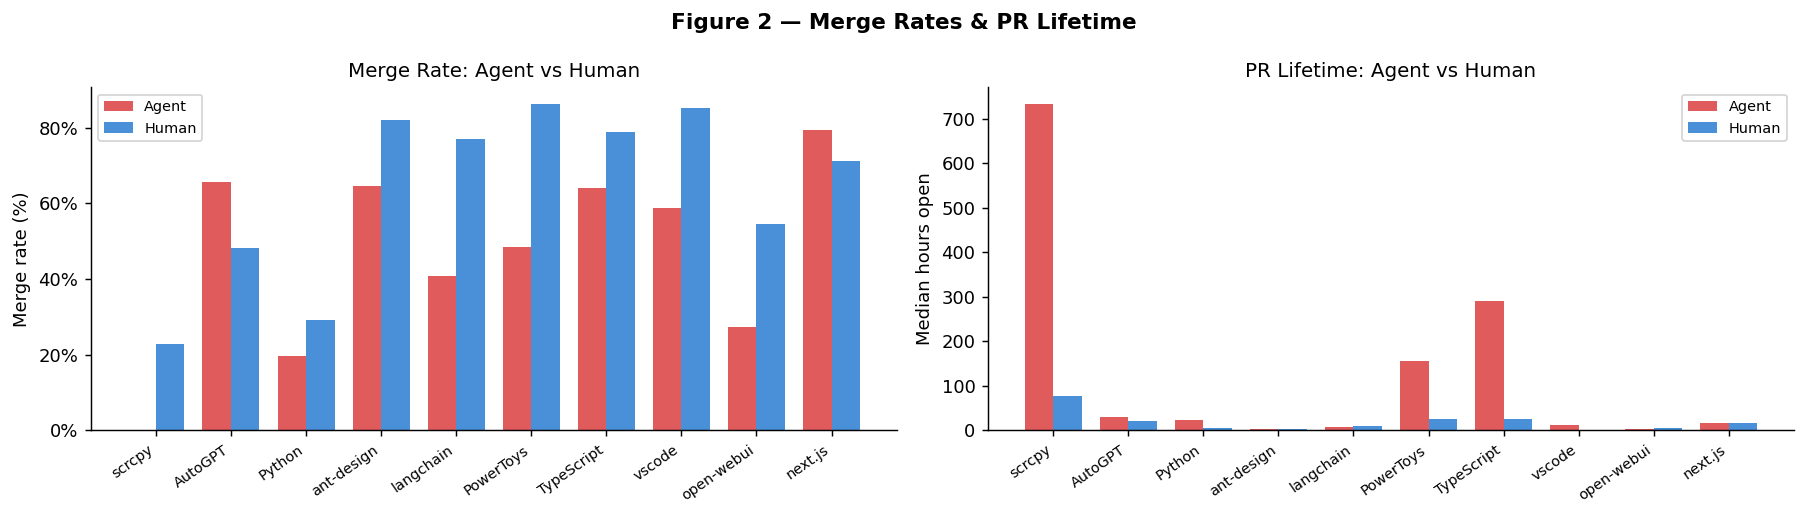

In [14]:
# ── 7. Figure 2: Merge Rates & PR Lifetime ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

agent_merge = [repo_stats[(r, "agent")]["merge_rate"]     for r in repos]
human_merge = [repo_stats[(r, "human")]["merge_rate"]     for r in repos]
agent_life  = [repo_stats[(r, "agent")]["med_lifetime_h"] or 0 for r in repos]
human_life  = [repo_stats[(r, "human")]["med_lifetime_h"] or 0 for r in repos]

bar_pair(axes[0], agent_merge, human_merge, "Merge rate (%)", "Merge Rate: Agent vs Human", fmt="pct")
bar_pair(axes[1], agent_life,  human_life,  "Median hours open", "PR Lifetime: Agent vs Human")

plt.suptitle("Figure 2 — Merge Rates & PR Lifetime", fontweight="bold")
plt.tight_layout()
plt.show()


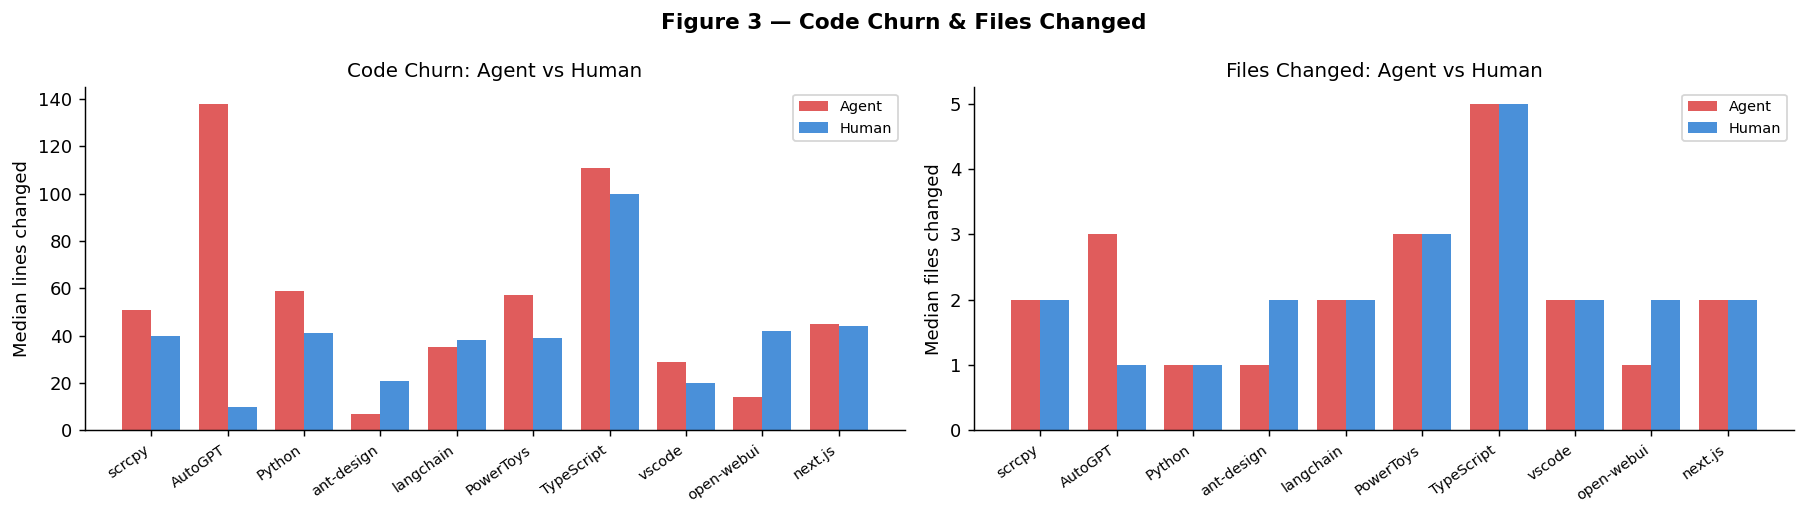

In [15]:
# ── 8. Figure 3: Code Churn & Files Changed ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

agent_churn = [repo_stats[(r, "agent")]["med_churn"] or 0 for r in repos]
human_churn = [repo_stats[(r, "human")]["med_churn"] or 0 for r in repos]
agent_files = [repo_stats[(r, "agent")]["med_files"] or 0 for r in repos]
human_files = [repo_stats[(r, "human")]["med_files"] or 0 for r in repos]

bar_pair(axes[0], agent_churn, human_churn, "Median lines changed", "Code Churn: Agent vs Human")
bar_pair(axes[1], agent_files, human_files, "Median files changed",  "Files Changed: Agent vs Human")

plt.suptitle("Figure 3 — Code Churn & Files Changed", fontweight="bold")
plt.tight_layout()
plt.show()


## Section 4 — Temporal Analysis: AI Agent vs Human Over Time


In [ ]:
# ── 9. Build monthly time-series ─────────────────────────────────────────
monthly_agent = defaultdict(int)
monthly_human = defaultdict(int)

for r in rows:
    dt = r["createdAt"]
    if dt is None:
        continue
    key = (dt.year, dt.month)
    if r["origin"] == "agent":
        monthly_agent[key] += 1
    else:
        monthly_human[key] += 1

all_keys = sorted(set(monthly_agent) | set(monthly_human))
all_keys = [k for k in all_keys if monthly_agent[k] + monthly_human[k] >= 5]

dates  = [datetime(k[0], k[1], 1, tzinfo=timezone.utc) for k in all_keys]
a_vals = [monthly_agent[k] for k in all_keys]
h_vals = [monthly_human[k] for k in all_keys]
total  = [a + h for a, h in zip(a_vals, h_vals)]
a_pct  = [a * 100 / t if t else 0 for a, t in zip(a_vals, total)]

def rolling_avg(vals, window=3):
    out = []
    for i in range(len(vals)):
        lo = max(0, i - window + 1)
        out.append(sum(vals[lo:i+1]) / (i - lo + 1))
    return out

a_pct_smooth = rolling_avg(a_pct, 3)
print(f"Monthly buckets: {len(dates)}  ({dates[0].strftime('%Y-%m')} → {dates[-1].strftime('%Y-%m')})")


Monthly buckets: 143  (2014-07 → 2026-05)


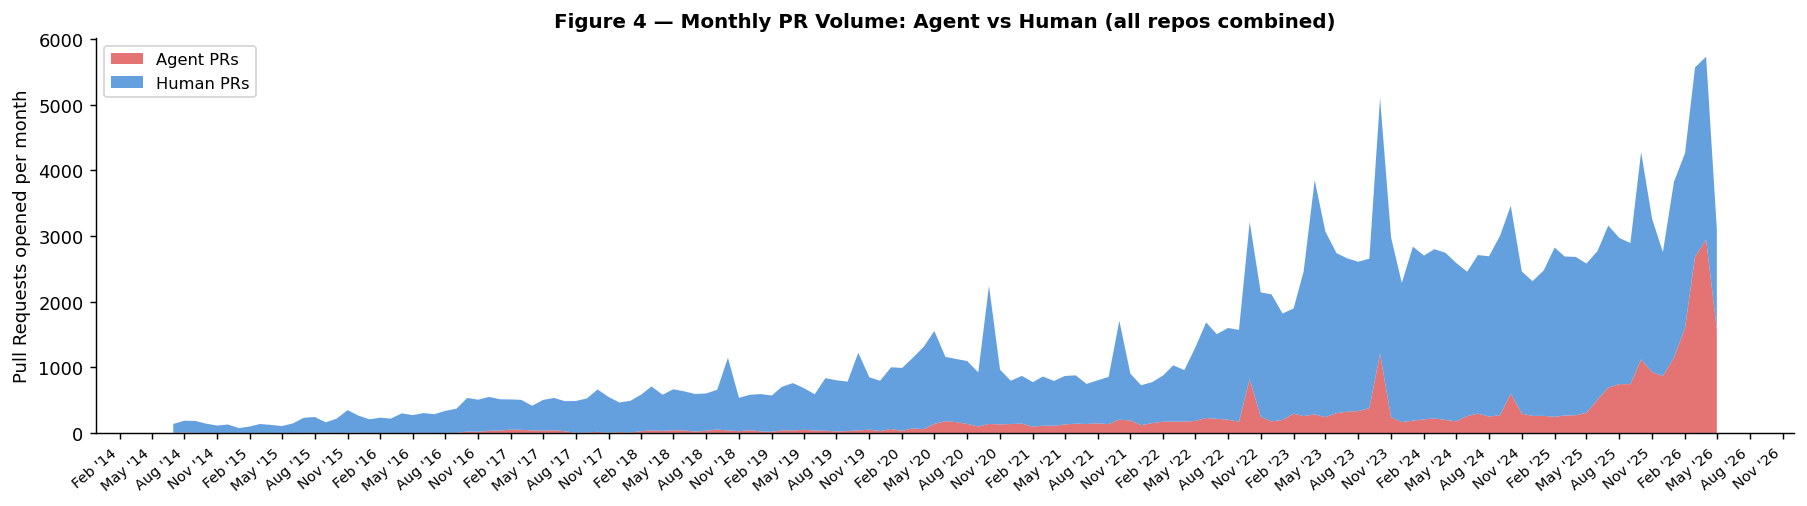

In [ ]:
# ── 10. Figure 4: Monthly stacked PR volume ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.stackplot(dates, a_vals, h_vals,
             labels=["Agent PRs", "Human PRs"],
             colors=[COLORS["agent"], COLORS["human"]],
             alpha=0.85)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Pull Requests opened per month")
ax.set_title("Figure 4 — Monthly PR Volume: Agent vs Human (all repos combined)", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


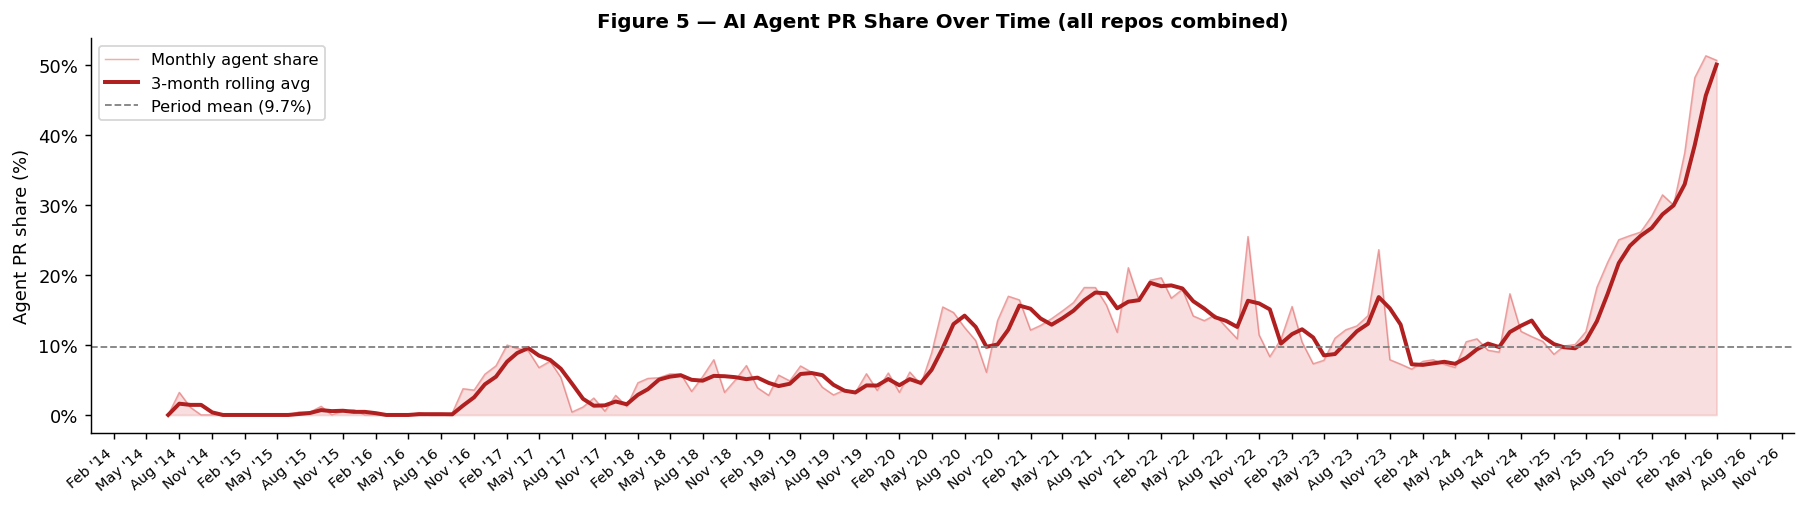

In [ ]:
# ── 11. Figure 5: Agent share trend over time ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(dates, a_pct, alpha=0.20, color=COLORS["agent"])
ax.plot(dates, a_pct, color=COLORS["agent"], linewidth=0.8, alpha=0.5, label="Monthly agent share")
ax.plot(dates, a_pct_smooth, color="#B02020", linewidth=2.2, label="3-month rolling avg")
ax.axhline(sum(a_pct) / len(a_pct), color="gray", linestyle="--", linewidth=1,
           label=f"Period mean ({sum(a_pct)/len(a_pct):.1f}%)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel("Agent PR share (%)")
ax.set_title("Figure 5 — AI Agent PR Share Over Time (all repos combined)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


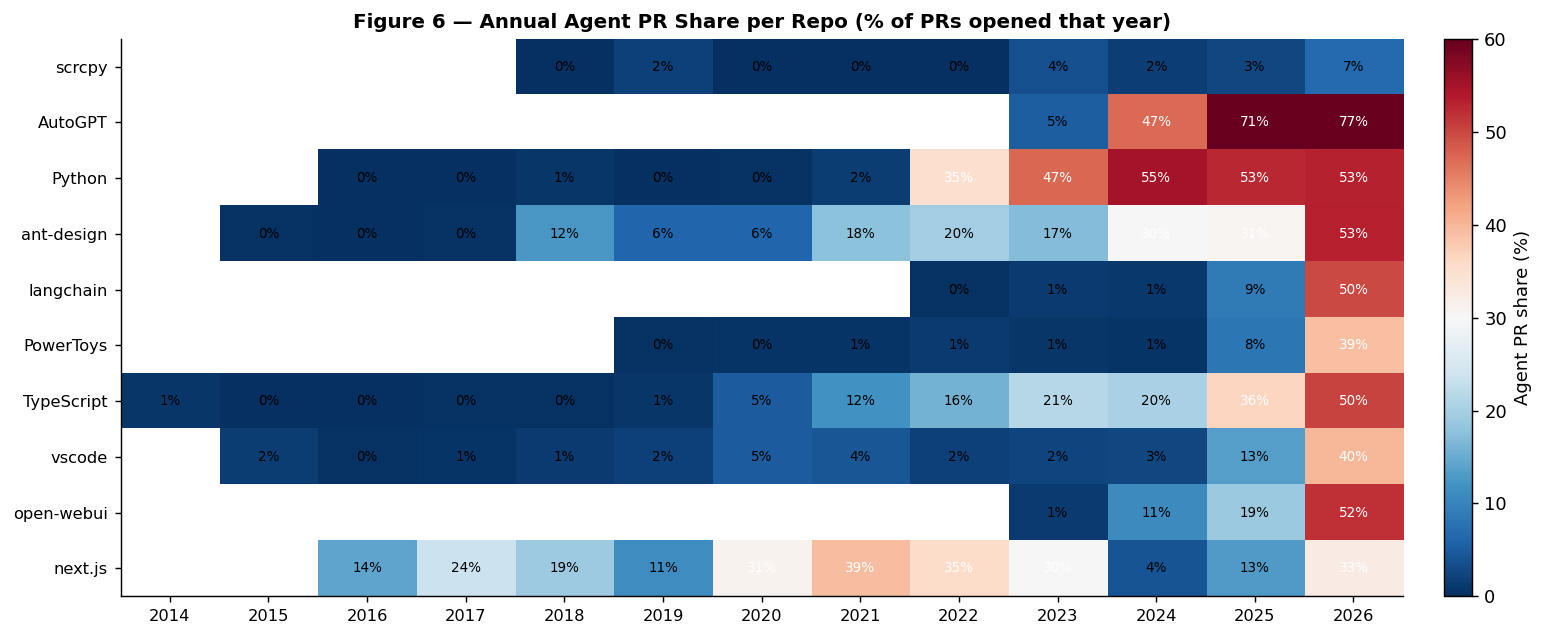

In [ ]:
# ── 12. Figure 6: Annual agent share heatmap per repo ────────────────────
yearly_by_repo = defaultdict(lambda: defaultdict(lambda: [0, 0]))
for r in rows:
    dt = r["createdAt"]
    if dt is None:
        continue
    yearly_by_repo[r["repo"]][dt.year][0 if r["origin"] == "agent" else 1] += 1

year_keys = sorted({r["createdAt"].year for r in rows if r["createdAt"]})
heat = np.full((len(repos), len(year_keys)), np.nan)

for ri, repo in enumerate(repos):
    for yi, year in enumerate(year_keys):
        a, h = yearly_by_repo[repo][year]
        total_y = a + h
        if total_y >= 5:
            heat[ri, yi] = a * 100 / total_y

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat, aspect="auto", cmap="RdBu_r", vmin=0, vmax=60)
ax.set_xticks(range(len(year_keys)))
ax.set_xticklabels(year_keys, fontsize=9)
ax.set_yticks(range(len(repos)))
ax.set_yticklabels([short_names[r] for r in repos], fontsize=9)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label("Agent PR share (%)")

for ri in range(len(repos)):
    for yi in range(len(year_keys)):
        val = heat[ri, yi]
        if not np.isnan(val):
            ax.text(yi, ri, f"{val:.0f}%", ha="center", va="center",
                    fontsize=7.5, color="white" if val > 30 else "black")

ax.set_title("Figure 6 — Annual Agent PR Share per Repo (% of PRs opened that year)", fontweight="bold")
plt.tight_layout()
plt.show()


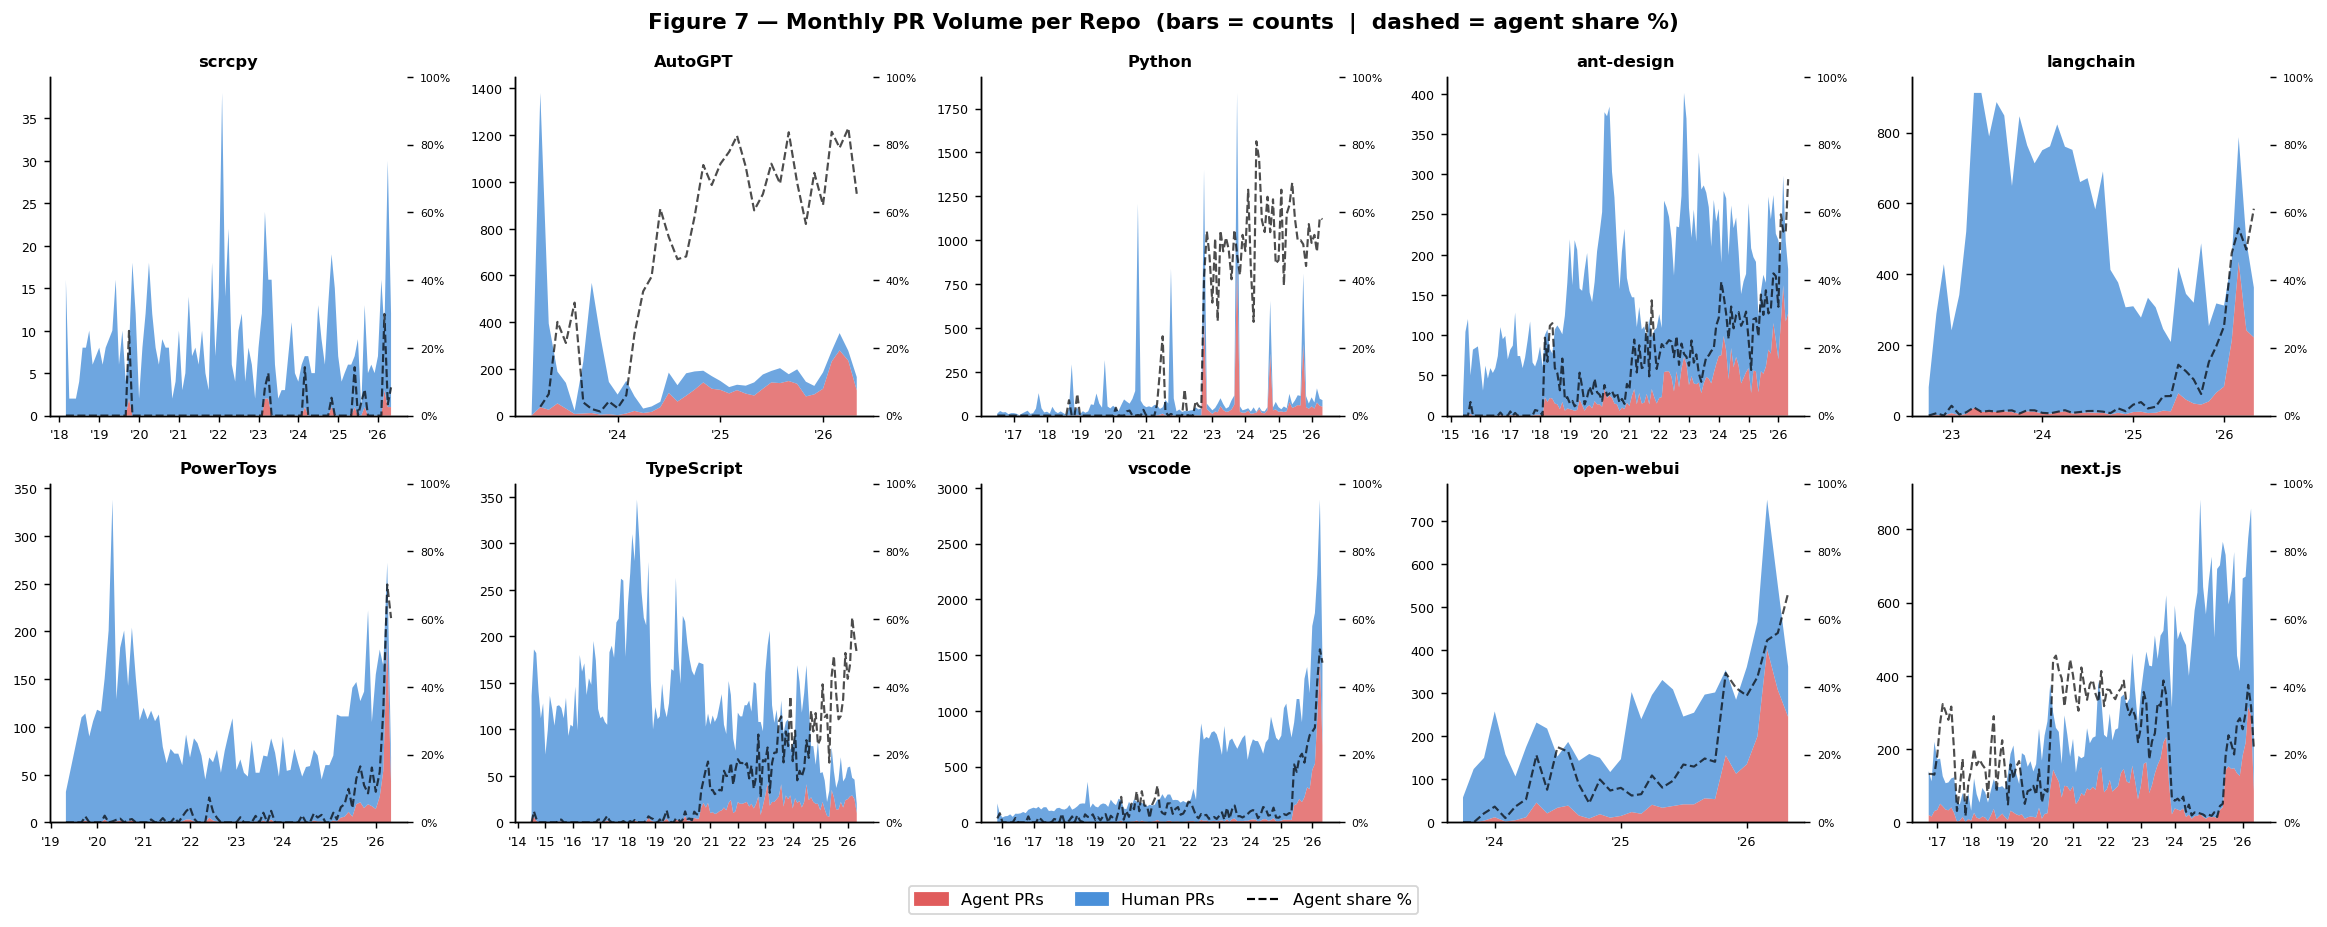

In [24]:
# ── 13. Figure 7: Per-repo monthly volume + agent % line ─────────────────
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

monthly_by_repo = defaultdict(lambda: defaultdict(lambda: [0, 0]))
for r in rows:
    dt = r["createdAt"]
    if dt is None:
        continue
    key = (dt.year, dt.month)
    monthly_by_repo[r["repo"]][key][0 if r["origin"] == "agent" else 1] += 1

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for idx, repo in enumerate(repos):
    ax = axes[idx]
    rkeys = sorted(monthly_by_repo[repo].keys())
    rdates = [datetime(k[0], k[1], 1, tzinfo=timezone.utc) for k in rkeys]
    ra = [monthly_by_repo[repo][k][0] for k in rkeys]
    rh = [monthly_by_repo[repo][k][1] for k in rkeys]
    rt = [a + h for a, h in zip(ra, rh)]
    rp = [a * 100 / t if t >= 3 else None for a, t in zip(ra, rt)]

    ax.stackplot(rdates, ra, rh, colors=[COLORS["agent"], COLORS["human"]], alpha=0.8)
    ax2 = ax.twinx()
    valid = [(d, p) for d, p in zip(rdates, rp) if p is not None]
    if valid:
        vd, vp = zip(*valid)
        ax2.plot(vd, vp, color="black", linewidth=1.2, linestyle="--", alpha=0.7)
        ax2.set_ylim(0, 100)
        ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax2.tick_params(axis="y", labelsize=6)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_title(short_names[repo], fontsize=9, fontweight="bold")

handles = [
    Patch(color=COLORS["agent"], label="Agent PRs"),
    Patch(color=COLORS["human"], label="Human PRs"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.2, label="Agent share %"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Figure 7 — Monthly PR Volume per Repo  (bars = counts  |  dashed = agent share %)",
             fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## Section 5 — Key Findings Summary


In [ ]:
# ── 14. Printed findings summary ─────────────────────────────────────────
print("=" * 62)
print("  KEY FINDINGS: AI Agent vs Human in Open-Source PRs")
print("=" * 62)

agent_rows = [r for r in rows if r["origin"] == "agent"]
human_rows = [r for r in rows if r["origin"] == "human"]
a_merged = sum(1 for r in agent_rows if r["is_merged"])
h_merged = sum(1 for r in human_rows if r["is_merged"])
total_prs = len(rows)

print(f"\n[VOLUME]")
print(f"  Total PRs analysed     : {total_prs:>8,}")
print(f"  Agent PRs              : {len(agent_rows):>8,}  ({pct(len(agent_rows), total_prs):.1f}%)")
print(f"  Human PRs              : {len(human_rows):>8,}  ({pct(len(human_rows), total_prs):.1f}%)")

print(f"\n[MERGE SUCCESS]")
print(f"  Agent merge rate       : {pct(a_merged, len(agent_rows)):.1f}%")
print(f"  Human merge rate       : {pct(h_merged, len(human_rows)):.1f}%")
gap = pct(h_merged, len(human_rows)) - pct(a_merged, len(agent_rows))
print(f"  → Humans merge {gap:.1f} percentage points more often")

print(f"\n[PR SIZE & COMPLEXITY]")
print(f"  Agent median churn     : {med([r['total_churn']   for r in agent_rows])} lines")
print(f"  Human median churn     : {med([r['total_churn']   for r in human_rows])} lines")
print(f"  Agent median files     : {med([r['changedFiles']  for r in agent_rows])}")
print(f"  Human median files     : {med([r['changedFiles']  for r in human_rows])}")

print(f"\n[PR LIFETIME]")
al = med([r['lifetime_hours'] for r in agent_rows])
hl = med([r['lifetime_hours'] for r in human_rows])
print(f"  Agent median lifetime  : {al:.1f} hours")
print(f"  Human median lifetime  : {hl:.1f} hours")
print(f"  → Agent PRs stay open {al - hl:.1f} h longer on median")

print(f"\n[HIGHEST AGENT ADOPTION]")
shares = [(repo, pct(repo_stats[(repo,'agent')]['n'],
                     repo_stats[(repo,'agent')]['n'] + repo_stats[(repo,'human')]['n']))
          for repo in repos]
for repo, share in sorted(shares, key=lambda x: -x[1]):
    bar = "█" * int(share / 2)
    print(f"  {repo:<38} {share:5.1f}%  {bar}")

print(f"\n[TEMPORAL TREND]")
if a_pct_smooth:
    first3 = sum(a_pct_smooth[:3]) / 3
    last3  = sum(a_pct_smooth[-3:]) / 3
    direction = "↑ RISING" if last3 > first3 + 2 else ("↓ FALLING" if last3 < first3 - 2 else "→ STABLE")
    print(f"  Early-period avg agent share : {first3:.1f}%")
    print(f"  Recent-period avg agent share: {last3:.1f}%")
    print(f"  Overall trend: {direction}")
print("=" * 62)


  KEY FINDINGS: AI Agent vs Human in Open-Source PRs

[VOLUME]
  Total PRs analysed     :  198,739
  Agent PRs              :   31,400  (15.8%)
  Human PRs              :  167,339  (84.2%)

[MERGE SUCCESS]
  Agent merge rate       : 57.9%
  Human merge rate       : 75.1%
  → Humans merge 17.2 percentage points more often

[PR SIZE & COMPLEXITY]
  Agent median churn     : 44.0 lines
  Human median churn     : 33 lines
  Agent median files     : 2.0
  Human median files     : 2

[PR LIFETIME]
  Agent median lifetime  : 13.8 hours
  Human median lifetime  : 6.3 hours
  → Agent PRs stay open 7.5 h longer on median

[HIGHEST AGENT ADOPTION]
  Significant-Gravitas/AutoGPT            39.8%  ███████████████████
  TheAlgorithms/Python                    28.0%  █████████████
  open-webui/open-webui                   26.1%  █████████████
  vercel/next.js                          21.7%  ██████████
  ant-design/ant-design                   17.7%  ████████
  microsoft/vscode                        1

In [25]:
# ── A. Tier assignment & RQ1 adoption onset ──────────────────────────────
from datetime import datetime, timezone

TIERS = {
    "Significant-Gravitas/AutoGPT":  "AI-native",
    "open-webui/open-webui":         "AI-native",
    "langchain-ai/langchain":        "AI-native",
    "TheAlgorithms/Python":          "General",
    "vercel/next.js":                "General",
    "ant-design/ant-design":         "General",
    "microsoft/vscode":              "General",
    "microsoft/TypeScript":          "General",
    "microsoft/PowerToys":           "General",
    "Genymobile/scrcpy":             "Systems",
}

# For each repo find first month agent share crossed 5%
adoption_onset = {}
for repo in repos:
    rkeys = sorted(monthly_by_repo[repo].keys())
    for k in rkeys:
        a, h = monthly_by_repo[repo][k]
        total_k = a + h
        if total_k >= 5 and (a * 100 / total_k) >= 5:
            adoption_onset[repo] = datetime(k[0], k[1], 1)
            break

print(f"\n{'Repository':<42} {'Tier':<12} {'Adoption onset':<18} {'2025-26 agent share':>20}")
print("─" * 96)
for repo in repos:
    tier  = TIERS.get(repo, "Unknown")
    onset = adoption_onset.get(repo, None)
    onset_str = onset.strftime("%Y-%m") if onset else "Not yet"
    # 2025-2026 mean agent share
    recent = [
        monthly_by_repo[repo][k]
        for k in monthly_by_repo[repo]
        if k[0] in (2025, 2026)
    ]
    if recent:
        ra = sum(v[0] for v in recent)
        rt = sum(v[0] + v[1] for v in recent)
        recent_share = f"{ra*100/rt:.1f}%" if rt else "N/A"
    else:
        recent_share = "N/A"
    print(f"{repo:<42} {tier:<12} {onset_str:<18} {recent_share:>20}")

# Tier-level summary
print("\n\nTIER SUMMARY")
print(f"{'Tier':<12} {'Repos':>6} {'Mean onset year':>16} {'Mean 2025-26 share':>20}")
print("─" * 58)
for tier in ["AI-native", "General", "Systems"]:
    tier_repos = [r for r in repos if TIERS.get(r) == tier]
    onsets = [adoption_onset[r].year for r in tier_repos if r in adoption_onset]
    recent_shares = []
    for repo in tier_repos:
        recent = [monthly_by_repo[repo][k] for k in monthly_by_repo[repo] if k[0] in (2025, 2026)]
        if recent:
            ra = sum(v[0] for v in recent)
            rt = sum(v[0]+v[1] for v in recent)
            if rt: recent_shares.append(ra*100/rt)
    mean_onset = f"{sum(onsets)/len(onsets):.1f}" if onsets else "N/A"
    mean_share = f"{sum(recent_shares)/len(recent_shares):.1f}%" if recent_shares else "N/A"
    print(f"{tier:<12} {len(tier_repos):>6} {mean_onset:>16} {mean_share:>20}")


Repository                                 Tier         Adoption onset      2025-26 agent share
────────────────────────────────────────────────────────────────────────────────────────────────
Genymobile/scrcpy                          Systems      2019-10                            4.7%
Significant-Gravitas/AutoGPT               AI-native    2023-05                           73.6%
TheAlgorithms/Python                       General      2018-12                           52.7%
ant-design/ant-design                      General      2018-03                           37.6%
langchain-ai/langchain                     AI-native    2025-05                           24.6%
microsoft/PowerToys                        General      2022-06                           19.6%
microsoft/TypeScript                       General      2020-09                           40.3%
microsoft/vscode                           General      2019-11                           25.5%
open-webui/open-webui                 

In [ ]:
# Compute time from repo creation to adoption onset per repo
repo_creation = {}
for r in rows:
    repo = r["repo"]
    dt = r["createdAt"]
    if dt is None:
        continue
    # Strip timezone info to make naive
    if hasattr(dt, 'tzinfo') and dt.tzinfo is not None:
        dt = dt.replace(tzinfo=None)
    if repo not in repo_creation or dt < repo_creation[repo]:
        repo_creation[repo] = dt

print("Time from repo creation to adoption onset (years):")
times = []
for repo in repos:
    onset = adoption_onset.get(repo)
    creation = repo_creation.get(repo)
    if onset and creation:
        # Make onset naive too if needed
        onset_naive = onset.replace(tzinfo=None) if hasattr(onset, 'tzinfo') and onset.tzinfo else onset
        years = (onset_naive - creation).days / 365.25
        times.append(years)
        print(f"  {repo.split('/')[1]:<30} {years:.1f} years")

print(f"\nMedian: {sorted(times)[len(times)//2]:.1f} years")
print(f"Min:    {min(times):.1f} years")
print(f"Max:    {max(times):.1f} years")

Time from repo creation to adoption onset (years):
  scrcpy                         1.6 years
  AutoGPT                        0.1 years
  Python                         2.3 years
  ant-design                     2.7 years
  langchain                      2.5 years
  PowerToys                      3.1 years
  TypeScript                     6.1 years
  vscode                         4.0 years
  open-webui                     0.4 years
  next.js                        -0.0 years

Median: 2.5 years
Min:    -0.0 years
Max:    6.1 years


In [ ]:
# ── B. RQ1 adoption growth rate (steepest 6-month window) ────────────────
print(f"\n{'Repository':<42} {'Steepest 6-month window':<26} {'Growth (pp)':>12}")
print("─" * 84)

for repo in repos:
    rkeys = sorted(monthly_by_repo[repo].keys())
    shares = []
    for k in rkeys:
        a, h = monthly_by_repo[repo][k]
        t = a + h
        if t >= 5:
            shares.append((datetime(k[0], k[1], 1), a * 100 / t))

    if len(shares) < 6:
        print(f"{repo:<42} {'Insufficient data':<26} {'N/A':>12}")
        continue

    max_growth = 0
    best_window = None
    for i in range(len(shares) - 5):
        growth = shares[i+5][1] - shares[i][1]
        if growth > max_growth:
            max_growth = growth
            best_window = f"{shares[i][0].strftime('%Y-%m')} to {shares[i+5][0].strftime('%Y-%m')}"

    print(f"{repo:<42} {best_window or 'N/A':<26} {max_growth:>+11.1f}pp")


Repository                                 Steepest 6-month window     Growth (pp)
────────────────────────────────────────────────────────────────────────────────────
Genymobile/scrcpy                          2025-10 to 2026-03               +30.0pp
Significant-Gravitas/AutoGPT               2024-01 to 2024-06               +58.8pp
TheAlgorithms/Python                       2022-06 to 2022-11               +54.4pp
ant-design/ant-design                      2025-09 to 2026-02               +29.2pp
langchain-ai/langchain                     2025-10 to 2026-03               +48.9pp
microsoft/PowerToys                        2025-11 to 2026-04               +61.7pp
microsoft/TypeScript                       2025-10 to 2026-03               +29.0pp
microsoft/vscode                           2025-11 to 2026-04               +28.4pp
open-webui/open-webui                      2025-10 to 2026-03               +35.9pp
vercel/next.js                             2020-02 to 2020-07              

In [31]:
# Robustness check: post-2022 adoption onset dates only
print("POST-2022 ROBUSTNESS CHECK: Adoption onset dates")
print("Restricting to PRs created 2022 or later\n")

post2022_onset = {}
for repo in repos:
    rkeys = sorted(k for k in monthly_by_repo[repo].keys() if k[0] >= 2022)
    for k in rkeys:
        a, h = monthly_by_repo[repo][k]
        t = a + h
        if t >= 5 and (a * 100 / t) >= 5:
            post2022_onset[repo] = datetime(k[0], k[1], 1)
            break

print(f"{'Repository':<42} {'Tier':<12} {'Full onset':<15} {'Post-2022 onset':<18}")
print("─" * 90)
for repo in repos:
    tier = TIERS.get(repo, "Unknown")
    full = adoption_onset.get(repo)
    post = post2022_onset.get(repo)
    full_str = full.strftime("%Y-%m") if full else "N/A"
    post_str = post.strftime("%Y-%m") if post else "Not reached"
    print(f"{repo:<42} {tier:<12} {full_str:<15} {post_str:<18}")

# Compute pos

POST-2022 ROBUSTNESS CHECK: Adoption onset dates
Restricting to PRs created 2022 or later

Repository                                 Tier         Full onset      Post-2022 onset   
──────────────────────────────────────────────────────────────────────────────────────────
Genymobile/scrcpy                          Systems      2019-10         2023-03           
Significant-Gravitas/AutoGPT               AI-native    2023-05         2023-05           
TheAlgorithms/Python                       General      2018-12         2022-03           
ant-design/ant-design                      General      2018-03         2022-01           
langchain-ai/langchain                     AI-native    2025-05         2025-05           
microsoft/PowerToys                        General      2022-06         2022-06           
microsoft/TypeScript                       General      2020-09         2022-01           
microsoft/vscode                           General      2019-11         2022-01           

In [27]:
# ── C. RQ2 annual merge rates and quality gap ────────────────────────────
import numpy as np

print("ANNUAL MERGE RATES BY CONTRIBUTOR TYPE AND REPOSITORY")
print("=" * 90)

# Collect all years that have meaningful data
all_years = sorted({r["createdAt"].year for r in rows if r["createdAt"] and r["createdAt"].year >= 2019})

# Header
header = f"{'Repository':<32} {'Type':<7}"
for yr in all_years:
    header += f"  {yr:>6}"
print(header)
print("─" * (32 + 7 + len(all_years) * 8))

for repo in repos:
    for origin in ("agent", "human"):
        line = f"{repo.split('/')[1]:<32} {origin:<7}"
        for yr in all_years:
            g = [r for r in rows if r["repo"] == repo
                 and r["origin"] == origin
                 and r["createdAt"] and r["createdAt"].year == yr]
            if len(g) >= 5:
                mr = sum(1 for r in g if r["is_merged"]) * 100 / len(g)
                line += f"  {mr:>5.1f}%"
            else:
                line += f"  {'—':>6}"
        print(line)
    print()

# Quality gap table (human rate minus agent rate per year)
print("\nQUALITY GAP (Human merge rate − Agent merge rate) per year")
print("Positive = humans merge more; narrowing gap = agents improving")
print("─" * (32 + 7 + len(all_years) * 8))

for repo in repos:
    line = f"{repo.split('/')[1]:<32} {'gap':<7}"
    for yr in all_years:
        ag = [r for r in rows if r["repo"] == repo and r["origin"] == "agent"
              and r["createdAt"] and r["createdAt"].year == yr]
        hg = [r for r in rows if r["repo"] == repo and r["origin"] == "human"
              and r["createdAt"] and r["createdAt"].year == yr]
        if len(ag) >= 5 and len(hg) >= 5:
            a_mr = sum(1 for r in ag if r["is_merged"]) * 100 / len(ag)
            h_mr = sum(1 for r in hg if r["is_merged"]) * 100 / len(hg)
            gap = h_mr - a_mr
            line += f"  {gap:>+6.1f}"
        else:
            line += f"  {'—':>6}"
    print(line)

ANNUAL MERGE RATES BY CONTRIBUTOR TYPE AND REPOSITORY
Repository                       Type       2019    2020    2021    2022    2023    2024    2025    2026
───────────────────────────────────────────────────────────────────────────────────────────────────────
scrcpy                           agent         —       —       —       —       —       —       —    0.0%
scrcpy                           human     25.0%    2.1%   11.5%   34.3%   14.7%   33.6%    8.3%   44.3%

AutoGPT                          agent         —       —       —       —   51.4%   78.8%   63.0%   62.2%
AutoGPT                          human         —       —       —       —   44.0%   48.5%   72.0%   47.6%

Python                           agent         —   33.3%   82.6%   26.1%   23.1%   17.7%   13.1%    7.3%
Python                           human     50.5%   32.5%   24.0%   15.1%   21.2%   18.2%    8.7%    6.2%

ant-design                       agent     58.3%   46.2%   54.1%   65.9%   72.4%   54.0%   73.8%   76.9%

In [ ]:
# ── D. RQ2 statistical tests (proportion test + Mann-Whitney) ────────────
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

print("STATISTICAL TESTS: Agent vs Human merge rate per repo")
print("Two-sample proportion z-test; BH correction applied")
print(f"{'Repository':<32} {'Agent n':>8} {'Human n':>8} {'Agent%':>8} {'Human%':>8} {'p-value':>10} {'sig':>5}")
print("─" * 85)

raw_pvals = []
test_results = []

for repo in repos:
    ag = [r for r in rows if r["repo"] == repo and r["origin"] == "agent"]
    hg = [r for r in rows if r["repo"] == repo and r["origin"] == "human"]
    if len(ag) < 10 or len(hg) < 10:
        continue
    a_m = sum(1 for r in ag if r["is_merged"])
    h_m = sum(1 for r in hg if r["is_merged"])
    count = np.array([a_m, h_m])
    nobs  = np.array([len(ag), len(hg)])
    _, p = proportions_ztest(count, nobs)
    raw_pvals.append(p)
    test_results.append((repo, len(ag), len(hg),
                         a_m*100/len(ag), h_m*100/len(hg), p))

# Benjamini-Hochberg correction
sorted_idx = np.argsort([t[5] for t in test_results])
bh_pvals = np.zeros(len(test_results))
m = len(test_results)
for rank, idx in enumerate(sorted_idx):
    bh_pvals[idx] = min(test_results[idx][5] * m / (rank + 1), 1.0)

for i, (repo, an, hn, am, hm, p) in enumerate(test_results):
    sig = "***" if bh_pvals[i] < 0.001 else ("**" if bh_pvals[i] < 0.01
          else ("*" if bh_pvals[i] < 0.05 else "ns"))
    print(f"{repo.split('/')[1]:<32} {an:>8,} {hn:>8,} {am:>7.1f}% {hm:>7.1f}% {bh_pvals[i]:>10.4f} {sig:>5}")

# Mann-Whitney on PR lifetime
print("\nMANN-WHITNEY U TEST: Agent vs Human PR lifetime per repo")
print(f"{'Repository':<32} {'Agent med (h)':>14} {'Human med (h)':>14} {'p-value':>10} {'sig':>5}")
print("─" * 80)

mw_pvals = []
mw_results = []
for repo in repos:
    ag_life = [r["lifetime_hours"] for r in rows if r["repo"] == repo
               and r["origin"] == "agent" and r["lifetime_hours"] is not None]
    hg_life = [r["lifetime_hours"] for r in rows if r["repo"] == repo
               and r["origin"] == "human" and r["lifetime_hours"] is not None]
    if len(ag_life) < 10 or len(hg_life) < 10:
        continue
    stat, p = stats.mannwhitneyu(ag_life, hg_life, alternative="two-sided")
    mw_pvals.append(p)
    mw_results.append((repo, np.median(ag_life), np.median(hg_life), p))

sorted_idx2 = np.argsort([t[3] for t in mw_results])
bh_mw = np.zeros(len(mw_results))
m2 = len(mw_results)
for rank, idx in enumerate(sorted_idx2):
    bh_mw[idx] = min(mw_results[idx][3] * m2 / (rank + 1), 1.0)

for i, (repo, am, hm, p) in enumerate(mw_results):
    sig = "***" if bh_mw[i] < 0.001 else ("**" if bh_mw[i] < 0.01
          else ("*" if bh_mw[i] < 0.05 else "ns"))
    print(f"{repo.split('/')[1]:<32} {am:>13.1f}h {hm:>13.1f}h {bh_mw[i]:>10.4f} {sig:>5}")

STATISTICAL TESTS: Agent vs Human merge rate per repo
Two-sample proportion z-test; BH correction applied
Repository                        Agent n  Human n   Agent%   Human%    p-value   sig
─────────────────────────────────────────────────────────────────────────────────────
scrcpy                                 15      853     0.0%    22.7%     0.0361     *
AutoGPT                             3,201    4,847    65.6%    48.1%     0.0000   ***
Python                              3,614    9,308    19.6%    29.1%     0.0000   ***
ant-design                          3,991   18,604    64.6%    81.9%     0.0000   ***
langchain                           1,734   21,238    40.7%    76.9%     0.0000   ***
PowerToys                             492    7,778    48.4%    86.4%     0.0000   ***
TypeScript                          1,471   17,988    64.2%    78.9%     0.0000   ***
vscode                              6,626   51,441    58.8%    85.3%     0.0000   ***
open-webui                        

In [ ]:
# ── E. RQ3 interrupted time series on human reviewer behavior ────────────
import statsmodels.formula.api as smf
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Step 1: compute intervention point per repo (first month agent share > 10%)
intervention = {}
for repo in repos:
    rkeys = sorted(monthly_by_repo[repo].keys())
    for k in rkeys:
        a, h = monthly_by_repo[repo][k]
        t = a + h
        if t >= 5 and (a * 100 / t) >= 10:
            intervention[repo] = k
            break

print("Intervention points (first month agent share > 10%):")
for repo in repos:
    iv = intervention.get(repo)
    print(f"  {repo.split('/')[1]:<30} {str(iv) if iv else 'Not reached'}")

# Step 2: build monthly reviewer metrics on human PRs only
# Need first_review_at -- extract from timeline
rows_ext = []
for r in rows:
    if r["origin"] != "human":
        continue
    rows_ext.append(r)

# Re-extract first review timestamp -- requires access to original pr data
# If you stored timeline in rows, extract here; otherwise approximate with review_count
# This version uses review_count and comment_count as proxies
human_monthly_metrics = defaultdict(lambda: {"review_counts": [], "comment_counts": [], "lifetimes": []})

for r in rows_ext:
    dt = r["createdAt"]
    if dt is None:
        continue
    key = (r["repo"], dt.year, dt.month)
    human_monthly_metrics[key]["review_counts"].append(r["review_count"])
    human_monthly_metrics[key]["comment_counts"].append(r["totalComments"])
    if r["lifetime_hours"] is not None:
        human_monthly_metrics[key]["lifetimes"].append(r["lifetime_hours"])

# Step 3: ITS regression per repo
print("\n\nINTERRUPTED TIME SERIES RESULTS")
print("Dependent variable: mean review count per human PR per month")
print(f"{'Repository':<30} {'β1 (trend)':>12} {'β2 (level shift)':>18} {'β3 (slope change)':>18} {'R²':>6}")
print("─" * 90)

its_results = []
for repo in repos:
    iv = intervention.get(repo)
    if iv is None:
        continue

    rkeys = sorted(k for k in human_monthly_metrics if k[0] == repo)
    if len(rkeys) < 12:
        continue

    records = []
    for idx, k in enumerate(rkeys):
        _, yr, mo = k
        month_dt = datetime(yr, mo, 1)
        key_tuple = (yr, mo)
        D = 1 if key_tuple >= iv else 0
        t_int_idx = next((i for i, k2 in enumerate(rkeys) if (k2[1], k2[2]) == iv), idx)
        t_since = max(0, idx - t_int_idx)
        metrics = human_monthly_metrics[k]
        if len(metrics["review_counts"]) < 3:
            continue
        records.append({
            "t": idx,
            "D": D,
            "t_since": t_since,
            "mean_reviews":  np.mean(metrics["review_counts"]),
            "mean_comments": np.mean(metrics["comment_counts"]),
            "mean_lifetime": np.mean(metrics["lifetimes"]) if metrics["lifetimes"] else np.nan,
        })

    if len(records) < 8:
        continue

    df_its = pd.DataFrame(records).dropna(subset=["mean_reviews"])
    try:
        model = smf.ols("mean_reviews ~ t + D + t_since", data=df_its).fit()
        b1 = model.params.get("t", np.nan)
        b2 = model.params.get("D", np.nan)
        b3 = model.params.get("t_since", np.nan)
        r2 = model.rsquared
        p2 = model.pvalues.get("D", np.nan)
        p3 = model.pvalues.get("t_since", np.nan)

        def stars(p):
            if p < 0.001: return "***"
            elif p < 0.01: return "**"
            elif p < 0.05: return "*"
            else: return ""

        its_results.append({
            "repo": repo, "b1": b1, "b2": b2, "b3": b3,
            "r2": r2, "p2": p2, "p3": p3,
            "stars2": stars(p2), "stars3": stars(p3)
        })
        print(f"{repo.split('/')[1]:<30} {b1:>+12.4f} "
              f"{b2:>+18.4f}{stars(p2):<3} "
              f"{b3:>+18.4f}{stars(p3):<3} "
              f"{r2:>6.3f}")
    except Exception as e:
        print(f"{repo.split('/')[1]:<30} model failed: {e}")

# Tier-level aggregation
print("\n\nTIER-LEVEL AGGREGATION OF ITS COEFFICIENTS")
print(f"{'Tier':<12} {'Mean β2 (level shift)':>22} {'Mean β3 (slope change)':>24}")
print("─" * 62)
for tier in ["AI-native", "General", "Systems"]:
    tier_res = [r for r in its_results if TIERS.get(r["repo"]) == tier]
    if tier_res:
        mean_b2 = np.mean([r["b2"] for r in tier_res])
        mean_b3 = np.mean([r["b3"] for r in tier_res])
        print(f"{tier:<12} {mean_b2:>+22.4f} {mean_b3:>+24.4f}")

Intervention points (first month agent share > 10%):
  scrcpy                         (2019, 10)
  AutoGPT                        (2023, 6)
  Python                         (2021, 6)
  ant-design                     (2018, 3)
  langchain                      (2025, 7)
  PowerToys                      (2025, 8)
  TypeScript                     (2020, 10)
  vscode                         (2021, 1)
  open-webui                     (2024, 5)
  next.js                        (2016, 10)


INTERRUPTED TIME SERIES RESULTS
Dependent variable: mean review count per human PR per month
Repository                       β1 (trend)   β2 (level shift)  β3 (slope change)     R²
──────────────────────────────────────────────────────────────────────────────────────────
scrcpy                              -0.0369            +0.3533               +0.0348     0.046
AutoGPT                             -0.6458            -0.3356               +0.7332     0.571
Python                              +0.0383      

In [ ]:

# ── E2. ITS for comment count and time-to-first-review (mean_lifetime proxy) ──
# Compute median beta2 across repos for the two additional metrics
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

its_comment_b2 = []
its_lifetime_b2 = []

for repo in repos:
    iv = intervention.get(repo)
    if iv is None:
        continue

    rkeys = sorted(k for k in human_monthly_metrics if k[0] == repo)
    if len(rkeys) < 12:
        continue

    records = []
    for idx, k in enumerate(rkeys):
        _, yr, mo = k
        key_tuple = (yr, mo)
        D = 1 if key_tuple >= iv else 0
        t_int_idx = next((i for i, k2 in enumerate(rkeys) if (k2[1], k2[2]) == iv), idx)
        t_since = max(0, idx - t_int_idx)
        m = human_monthly_metrics[k]
        if len(m["review_counts"]) < 3:
            continue
        records.append({
            "t": idx,
            "D": D,
            "t_since": t_since,
            "mean_comments": np.mean(m["comment_counts"]),
            "mean_lifetime": np.mean(m["lifetimes"]) if m["lifetimes"] else np.nan,
        })

    if len(records) < 8:
        continue

    df = pd.DataFrame(records)

    # Comment count model
    df_c = df.dropna(subset=["mean_comments"])
    if len(df_c) >= 8:
        try:
            m_c = smf.ols("mean_comments ~ t + D + t_since", data=df_c).fit()
            its_comment_b2.append(m_c.params.get("D", np.nan))
        except Exception:
            pass

    # Lifetime model (proxy for time-to-first-review)
    df_l = df.dropna(subset=["mean_lifetime"])
    if len(df_l) >= 8:
        try:
            m_l = smf.ols("mean_lifetime ~ t + D + t_since", data=df_l).fit()
            its_lifetime_b2.append(m_l.params.get("D", np.nan))
        except Exception:
            pass

print("Median β₂ values across repositories:")
print(f"  Comment count  (mean_comments): median β₂ = {np.median(its_comment_b2):+.2f}  (n={len(its_comment_b2)} repos)")
print(f"  PR lifetime / time-to-review   : median β₂ = {np.median(its_lifetime_b2):+.2f} h  (n={len(its_lifetime_b2)} repos)")
print()
print("Per-repo β₂ (comment count):", [round(v, 3) for v in its_comment_b2])
print("Per-repo β₂ (lifetime/h):   ", [round(v, 3) for v in its_lifetime_b2])


Median β₂ values across repositories:
  Comment count  (mean_comments): median β₂ = -0.03  (n=10 repos)
  PR lifetime / time-to-review   : median β₂ = +38.44 h  (n=10 repos)

Per-repo β₂ (comment count): [np.float64(6.014), np.float64(-7.88), np.float64(-1.257), np.float64(-1.949), np.float64(0.494), np.float64(2.664), np.float64(4.168), np.float64(-0.553), np.float64(-1.158), np.float64(2.367)]
Per-repo β₂ (lifetime/h):    [np.float64(3862.469), np.float64(-1177.507), np.float64(30.169), np.float64(84.289), np.float64(46.711), np.float64(-301.242), np.float64(723.593), np.float64(-268.653), np.float64(4.757), np.float64(95.241)]


Saved: quality_gap_by_tier.pdf  &  quality_gap_by_tier.png


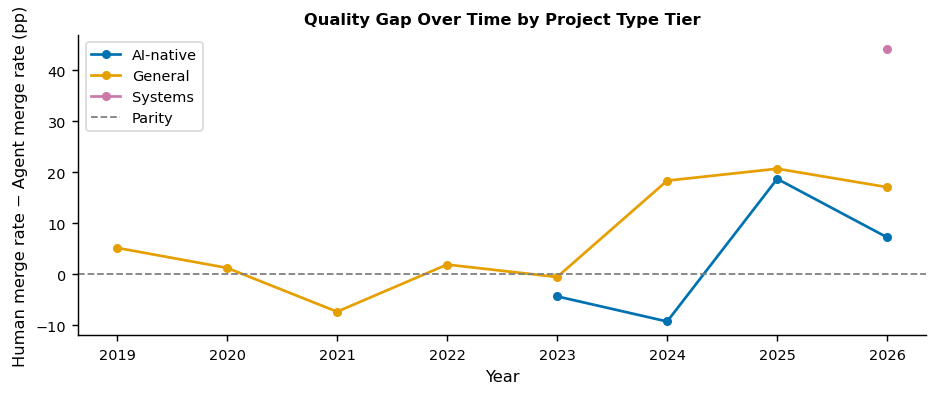

In [ ]:
# Quality gap trend by tier
tier_gap_by_year = {}
for tier in ["AI-native", "General", "Systems"]:
    tier_repos = [r for r in repos if TIERS.get(r) == tier]
    tier_gap_by_year[tier] = {}
    for yr in all_years:
        gaps = []
        for repo in tier_repos:
            ag = [r for r in rows if r["repo"]==repo and r["origin"]=="agent"
                  and r["createdAt"] and r["createdAt"].year==yr]
            hg = [r for r in rows if r["repo"]==repo and r["origin"]=="human"
                  and r["createdAt"] and r["createdAt"].year==yr]
            if len(ag) >= 5 and len(hg) >= 5:
                a_mr = sum(1 for r in ag if r["is_merged"])*100/len(ag)
                h_mr = sum(1 for r in hg if r["is_merged"])*100/len(hg)
                gaps.append(h_mr - a_mr)
        if gaps:
            tier_gap_by_year[tier][yr] = sum(gaps)/len(gaps)

# IEEE double-column figure: 7.16 in wide, 9pt fonts
fig, ax = plt.subplots(figsize=(7.16, 3.0))
# Okabe-Ito colorblind-safe palette
colors = {"AI-native": "#0072B2", "General": "#E69F00", "Systems": "#CC79A7"}
for tier, color in colors.items():
    yrs = sorted(tier_gap_by_year[tier].keys())
    vals = [tier_gap_by_year[tier][y] for y in yrs]
    ax.plot(yrs, vals, marker="o", label=tier, color=color, linewidth=1.5, markersize=4)
ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="Parity")
ax.set_xlabel("Year", fontsize=9)
ax.set_ylabel("Human merge rate − Agent merge rate (pp)", fontsize=9)
ax.set_title("Quality Gap Over Time by Project Type Tier", fontweight="bold", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
ax.legend(fontsize=8, framealpha=0.7)
plt.tight_layout(pad=0.5)
plt.savefig("quality_gap_by_tier.pdf", dpi=300, bbox_inches="tight")
plt.savefig("quality_gap_by_tier.png", dpi=300, bbox_inches="tight")
print("Saved: quality_gap_by_tier.pdf  &  quality_gap_by_tier.png")
plt.show()


In [ ]:
# Get exact annual gap for AutoGPT
repo = "Significant-Gravitas/AutoGPT"
for yr in range(2022, 2027):
    ag = [r for r in rows if r["repo"]==repo and r["origin"]=="agent"
          and r["createdAt"] and r["createdAt"].year==yr]
    hg = [r for r in rows if r["repo"]==repo and r["origin"]=="human"
          and r["createdAt"] and r["createdAt"].year==yr]
    if len(ag) >= 5 and len(hg) >= 5:
        a_mr = sum(1 for r in ag if r["is_merged"])*100/len(ag)
        h_mr = sum(1 for r in hg if r["is_merged"])*100/len(hg)
        gap = h_mr - a_mr
        print(f"{yr}: agent MR={a_mr:.1f}% human MR={h_mr:.1f}% gap={gap:+.1f}pp (n_agent={len(ag)}, n_human={len(hg)})")

2023: agent MR=51.4% human MR=44.0% gap=-7.4pp (n_agent=181, n_human=3226)
2024: agent MR=78.8% human MR=48.5% gap=-30.3pp (n_agent=704, n_human=791)
2025: agent MR=63.0% human MR=72.0% gap=+8.9pp (n_agent=1347, n_human=542)
2026: agent MR=62.2% human MR=47.6% gap=-14.7pp (n_agent=969, n_human=288)


In [ ]:
# Verify earliest PR date and repo creation dates
print("Repo creation dates (sorted):")
for repo, dt in sorted(repo_creation.items(), key=lambda x: x[1]):
    print(f"  {repo}: {dt}")

print("\nEarliest PR created_at per repo:")
for repo in repos:
    rp_prs = [pr for pr in prs if pr.get('repo') == repo]
    if rp_prs:
        earliest = min(pr['created_at'] for pr in rp_prs)
        print(f"  {repo}: {earliest[:10]}")

Repo creation dates (sorted):
  microsoft/TypeScript: 2014-07-14 23:53:15
  ant-design/ant-design: 2015-06-02 08:25:26
  microsoft/vscode: 2015-11-16 06:43:37
  TheAlgorithms/Python: 2016-07-26 16:54:19
  vercel/next.js: 2016-10-06 02:45:14
  Genymobile/scrcpy: 2018-03-10 07:10:31
  microsoft/PowerToys: 2019-05-05 21:22:26
  langchain-ai/langchain: 2022-10-17 03:21:12
  Significant-Gravitas/AutoGPT: 2023-03-16 22:53:21
  open-webui/open-webui: 2023-10-19 04:54:23

Earliest PR created_at per repo:


In [16]:
# ── F. Reviewer-requested robustness check: strict LLM-only classification × full-history vs. post-2022 ──
from collections import defaultdict
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings("ignore")

def build_monthly_by_repo(rows_subset, origin_field):
    m = defaultdict(lambda: defaultdict(lambda: [0, 0]))
    for r in rows_subset:
        dt = r["createdAt"]
        if dt is None:
            continue
        key = (dt.year, dt.month)
        m[r["repo"]][key][0 if r[origin_field] == "agent" else 1] += 1
    return m

def compute_onset(monthly, repos, threshold_pct=5, min_n=5):
    onset = {}
    for repo in repos:
        for k in sorted(monthly[repo].keys()):
            a, h = monthly[repo][k]
            t = a + h
            if t >= min_n and (a * 100 / t) >= threshold_pct:
                onset[repo] = datetime(k[0], k[1], 1)
                break
    return onset

def run_rq2(rows_subset, origin_field, repos):
    results = []
    for repo in repos:
        ag = [r for r in rows_subset if r["repo"] == repo and r[origin_field] == "agent"]
        hg = [r for r in rows_subset if r["repo"] == repo and r[origin_field] == "human"]
        if len(ag) < 10 or len(hg) < 10:
            continue
        a_m = sum(1 for r in ag if r["is_merged"])
        h_m = sum(1 for r in hg if r["is_merged"])
        count = np.array([a_m, h_m]); nobs = np.array([len(ag), len(hg)])
        _, p = proportions_ztest(count, nobs)
        results.append({"repo": repo, "n_agent": len(ag), "n_human": len(hg),
                         "agent_mr": a_m * 100 / len(ag), "human_mr": h_m * 100 / len(hg),
                         "gap": h_m * 100 / len(hg) - a_m * 100 / len(ag), "p": p})
    if results:
        pvals = [r["p"] for r in results]
        idx = np.argsort(pvals); m = len(results)
        bh = np.zeros(m)
        for rank, i in enumerate(idx):
            bh[i] = min(pvals[i] * m / (rank + 1), 1.0)
        for i, r in enumerate(results):
            r["p_bh"] = bh[i]
    return results

def run_rq3(rows_subset, origin_field, repos, monthly, threshold_pct=10):
    intervention = compute_onset(monthly, repos, threshold_pct=threshold_pct, min_n=5)
    human_monthly = defaultdict(lambda: {"review_counts": []})
    for r in rows_subset:
        if r[origin_field] != "human":
            continue
        dt = r["createdAt"]
        if dt is None:
            continue
        key = (r["repo"], dt.year, dt.month)
        human_monthly[key]["review_counts"].append(r["review_count"])

    its = []
    for repo in repos:
        iv = intervention.get(repo)
        if iv is None:
            continue
        iv_key = (iv.year, iv.month)
        rkeys = sorted(k for k in human_monthly if k[0] == repo)
        if len(rkeys) < 12:
            continue
        records = []
        for idx, k in enumerate(rkeys):
            _, yr, mo = k
            key_tuple = (yr, mo)
            D = 1 if key_tuple >= iv_key else 0
            t_int_idx = next((i for i, k2 in enumerate(rkeys) if (k2[1], k2[2]) == iv_key), idx)
            t_since = max(0, idx - t_int_idx)
            rc = human_monthly[k]["review_counts"]
            if len(rc) < 3:
                continue
            records.append({"t": idx, "D": D, "t_since": t_since, "mean_reviews": np.mean(rc)})
        if len(records) < 8:
            continue
        df_its = pd.DataFrame(records).dropna(subset=["mean_reviews"])
        try:
            model = smf.ols("mean_reviews ~ t + D + t_since", data=df_its).fit()
            its.append({"repo": repo,
                        "b1": model.params.get("t", np.nan),
                        "b2": model.params.get("D", np.nan),
                        "p2": model.pvalues.get("D", np.nan),
                        "b3": model.params.get("t_since", np.nan),
                        "p3": model.pvalues.get("t_since", np.nan),
                        "r2": model.rsquared})
        except Exception:
            pass
    return its

combos = [
    ("origin", None, "Broad (submitted) -- full history"),
    ("origin_strict", None, "Strict LLM-only -- full history"),
    ("origin", 2022, "Broad (submitted) -- post-2022 only"),
    ("origin_strict", 2022, "Strict LLM-only -- post-2022 only"),
    ("origin_corrected", None, "Corrected (documented methodology, fix/ removed) -- full history"),
    ("origin_corrected", 2022, "Corrected (documented methodology, fix/ removed) -- post-2022 only"),
]

for origin_field, year_min, label in combos:
    subset = rows if year_min is None else [r for r in rows if r["createdAt"] and r["createdAt"].year >= year_min]
    monthly = build_monthly_by_repo(subset, origin_field)
    onset = compute_onset(monthly, repos, threshold_pct=5)
    rq2 = run_rq2(subset, origin_field, repos)
    rq3 = run_rq3(subset, origin_field, repos, monthly, threshold_pct=10)
    intervention10 = compute_onset(monthly, repos, threshold_pct=10, min_n=5)

    print(f"\n{'=' * 100}\n{label}\n{'=' * 100}")
    print(f"{'Repo':<32} {'Onset(5%)':<10}")
    for repo in repos:
        o = onset.get(repo)
        print(f"{repo.split('/')[1]:<32} {o.strftime('%Y-%m') if o else 'N/A':<10}")
    print(f"\n{'Repo':<32} {'Interv.(10%)':<12}")
    for repo in repos:
        iv = intervention10.get(repo)
        print(f"{repo.split('/')[1]:<32} {iv.strftime('%Y-%m') if iv else 'N/A':<12}")
    print(f"\n{'Repo':<28} {'AgN':>6} {'HuN':>6} {'Ag%':>7} {'Hu%':>7} {'Gap':>7} {'p(BH)':>8}")
    for r in rq2:
        print(f"{r['repo'].split('/')[1]:<28} {r['n_agent']:>6} {r['n_human']:>6} "
              f"{r['agent_mr']:>6.1f}% {r['human_mr']:>6.1f}% {r['gap']:>+6.1f} {r['p_bh']:>8.4f}")
    print(f"\n{'Repo':<28} {'Beta1':>10} {'Beta2':>10} {'p2':>10} {'Beta3':>10} {'p3':>10} {'R2':>7}")
    for r in rq3:
        print(f"{r['repo'].split('/')[1]:<28} {r['b1']:>+10.4f} {r['b2']:>+10.4f} {r['p2']:>10.4f} "
              f"{r['b3']:>+10.4f} {r['p3']:>10.4f} {r['r2']:>7.3f}")


Broad (submitted) -- full history
Repo                             Onset(5%) 
scrcpy                           2019-10   
AutoGPT                          2023-05   
Python                           2018-12   
ant-design                       2018-03   
langchain                        2025-05   
PowerToys                        2022-06   
TypeScript                       2020-09   
vscode                           2019-11   
open-webui                       2024-04   
next.js                          2016-10   

Repo                             Interv.(10%)
scrcpy                           2019-10     
AutoGPT                          2023-06     
Python                           2021-06     
ant-design                       2018-03     
langchain                        2025-07     
PowerToys                        2025-08     
TypeScript                       2020-10     
vscode                           2021-01     
open-webui                       2024-05     
next.js             

In [17]:
# ── G. Follow-up: comment count and PR lifetime under the corrected classifier ──
# Adjust the two field names below if your rows dicts use different keys.
COMMENT_FIELD = "totalComments"     # per-PR comment count
LIFETIME_FIELD = "lifetime_hours"   # per-PR lifetime, human-authored PRs only

def run_rq3_metric(rows_subset, origin_field, repos, monthly, value_field,
                    threshold_pct=10, agg="mean"):
    """Same ITS structure as run_rq3, but generalized to any per-PR numeric field
    and to mean or median aggregation."""
    intervention = compute_onset(monthly, repos, threshold_pct=threshold_pct, min_n=5)
    human_monthly = defaultdict(lambda: {"values": []})
    for r in rows_subset:
        if r[origin_field] != "human":
            continue
        dt = r["createdAt"]
        if dt is None or r.get(value_field) is None:
            continue
        key = (r["repo"], dt.year, dt.month)
        human_monthly[key]["values"].append(r[value_field])

    its = []
    for repo in repos:
        iv = intervention.get(repo)
        if iv is None:
            continue
        iv_key = (iv.year, iv.month)
        rkeys = sorted(k for k in human_monthly if k[0] == repo)
        if len(rkeys) < 12:
            continue
        records = []
        for idx, k in enumerate(rkeys):
            _, yr, mo = k
            key_tuple = (yr, mo)
            D = 1 if key_tuple >= iv_key else 0
            t_int_idx = next((i for i, k2 in enumerate(rkeys) if (k2[1], k2[2]) == iv_key), idx)
            t_since = max(0, idx - t_int_idx)
            vals = human_monthly[k]["values"]
            if len(vals) < 3:
                continue
            agg_val = np.median(vals) if agg == "median" else np.mean(vals)
            records.append({"t": idx, "D": D, "t_since": t_since, "agg_val": agg_val})
        if len(records) < 8:
            continue
        df_its = pd.DataFrame(records).dropna(subset=["agg_val"])
        try:
            model = smf.ols("agg_val ~ t + D + t_since", data=df_its).fit()
            its.append({"repo": repo,
                        "b1": model.params.get("t", np.nan),
                        "b2": model.params.get("D", np.nan),
                        "p2": model.pvalues.get("D", np.nan),
                        "b3": model.params.get("t_since", np.nan),
                        "p3": model.pvalues.get("t_since", np.nan),
                        "r2": model.rsquared})
        except Exception:
            pass
    return its

# Run both metrics on the corrected, full-history classification (matches Table III)
subset = rows
monthly = build_monthly_by_repo(subset, "origin_corrected")

for label, field, agg in [
    ("Comment count (median)", COMMENT_FIELD, "median"),
    ("PR lifetime, hours (median)", LIFETIME_FIELD, "median"),
]:
    results = run_rq3_metric(subset, "origin_corrected", repos, monthly, field, agg=agg)
    print(f"\n{'=' * 90}\n{label} -- corrected classifier, full history\n{'=' * 90}")
    print(f"{'Repo':<28} {'Beta1':>10} {'Beta2':>10} {'p2':>10} {'Beta3':>10} {'p3':>10} {'R2':>7}")
    for r in results:
        print(f"{r['repo'].split('/')[1]:<28} {r['b1']:>+10.4f} {r['b2']:>+10.4f} {r['p2']:>10.4f} "
              f"{r['b3']:>+10.4f} {r['p3']:>10.4f} {r['r2']:>7.3f}")
    if not results:
        print("(no repos had enough data for this metric -- check the field name)")

    b2s = [r["b2"] for r in results]
    if b2s:
        print(f"\nMedian beta2 across repos: {np.median(b2s):+.4f}")


Comment count (median) -- corrected classifier, full history
Repo                              Beta1      Beta2         p2      Beta3         p3      R2
scrcpy                          -0.0590    +0.8310     0.7780    +0.0019     0.9963   0.096
AutoGPT                         +1.0000    -3.4362     0.2370    -0.8259     0.6468   0.690
Python                          +0.0279    -1.0352     0.0073    -0.0447     0.0009   0.216
ant-design                      +0.0465    -2.1133     0.0067    +0.0540     0.1245   0.717
langchain                       +0.0269    -0.9769     0.1665    -0.0269     0.9384   0.159
PowerToys                       +0.0377    +1.9665     0.0033    -0.5467     0.0000   0.479
TypeScript                      +0.0224    +0.3005     0.6605    -0.1777     0.0244   0.297
vscode                          -0.0287    +0.5767     0.0342    +0.2735     0.0000   0.808
open-webui                      +0.1786    -0.2923     0.4455    -0.1309     0.1027   0.667
next.js           

In [18]:
ts_key = [k for k in repos if "typescript" in k.lower()][0]
ts_lifetimes = sorted(
    ((r["createdAt"].year, r["createdAt"].month), r["lifetime_hours"])
    for r in rows if r["repo"] == ts_key and r["origin_corrected"] == "human" and r.get("lifetime_hours") is not None
)
from collections import defaultdict
monthly_ts = defaultdict(list)
for k, v in ts_lifetimes:
    monthly_ts[k].append(v)
for k in sorted(monthly_ts):
    vals = monthly_ts[k]
    print(f"{k[0]}-{k[1]:02d}  n={len(vals):3d}  median={np.median(vals):8.1f}h  max={max(vals):8.1f}h")

2014-07  n=136  median=    18.3h  max=   449.4h
2014-08  n=186  median=    23.2h  max=  4139.5h
2014-09  n=182  median=    22.1h  max=  3538.8h
2014-10  n=141  median=    16.2h  max=  3507.6h
2014-11  n=112  median=    10.2h  max=  7005.1h
2014-12  n=128  median=     7.0h  max= 15363.0h
2015-01  n= 73  median=    24.5h  max= 10779.1h
2015-02  n= 99  median=    19.7h  max=  1759.4h
2015-03  n=136  median=    16.2h  max=  4716.1h
2015-04  n=122  median=    25.2h  max=  4219.0h
2015-05  n=104  median=    16.3h  max=  4846.1h
2015-06  n=125  median=    16.8h  max= 13178.8h
2015-07  n=126  median=    45.7h  max= 13384.2h
2015-08  n=123  median=    22.5h  max= 12312.6h
2015-09  n=112  median=    21.0h  max= 11495.7h
2015-10  n=134  median=    24.6h  max= 13940.8h
2015-11  n= 93  median=    21.3h  max=  9932.0h
2015-12  n=105  median=    32.4h  max= 23370.3h
2016-01  n=103  median=    20.0h  max= 12049.2h
2016-02  n=146  median=    12.0h  max= 10828.3h
2016-03  n= 99  median=    14.0h  max= 1

In [19]:
pt_key = [k for k in repos if "powertoys" in k.lower()][0]
pt_reviews = sorted(
    ((r["createdAt"].year, r["createdAt"].month), r["review_count"])
    for r in rows if r["repo"] == pt_key and r["origin_corrected"] == "human" and r.get("review_count") is not None
)
from collections import defaultdict
monthly_pt = defaultdict(list)
for k, v in pt_reviews:
    monthly_pt[k].append(v)
for k in sorted(monthly_pt):
    vals = monthly_pt[k]
    print(f"{k[0]}-{k[1]:02d}  n={len(vals):3d}  mean={np.mean(vals):6.2f}  median={np.median(vals):6.1f}  max={max(vals):4d}")

2019-05  n= 32  mean=  0.31  median=   0.0  max=   2
2019-09  n=110  mean=  0.80  median=   0.0  max=   9
2019-10  n=114  mean=  1.35  median=   1.0  max=   9
2019-11  n= 90  mean=  3.80  median=   1.0  max=  46
2019-12  n=106  mean=  1.87  median=   1.0  max=  10
2020-01  n=118  mean=  3.05  median=   2.0  max=  19
2020-02  n=116  mean=  2.19  median=   1.0  max=  10
2020-03  n=148  mean=  1.89  median=   1.0  max=   9
2020-04  n=201  mean=  2.40  median=   1.0  max=  19
2020-05  n=338  mean=  2.43  median=   2.0  max=  20
2020-06  n=128  mean=  2.57  median=   2.0  max=  19
2020-07  n=181  mean=  2.19  median=   1.0  max=  47
2020-08  n=201  mean=  1.81  median=   1.0  max=  15
2020-09  n=142  mean=  1.87  median=   1.0  max=  24
2020-10  n=204  mean=  1.85  median=   1.0  max=  10
2020-11  n=151  mean=  2.19  median=   1.0  max=  14
2020-12  n=107  mean=  1.64  median=   1.0  max=   7
2021-01  n=120  mean=  2.51  median=   1.0  max=  19
2021-02  n=108  mean=  1.87  median=   1.0  ma

In [20]:
# ── H. Aggregate (pooled) acceptance gap under corrected classification ──
agent_rows_c = [r for r in rows if r["origin_corrected"] == "agent"]
human_rows_c = [r for r in rows if r["origin_corrected"] == "human"]

n_agent, n_human = len(agent_rows_c), len(human_rows_c)
agent_merged = sum(1 for r in agent_rows_c if r["is_merged"])
human_merged = sum(1 for r in human_rows_c if r["is_merged"])
agent_rate = agent_merged / n_agent * 100
human_rate = human_merged / n_human * 100

count = np.array([agent_merged, human_merged])
nobs = np.array([n_agent, n_human])
_, p_agg = proportions_ztest(count, nobs)

print("=" * 70)
print("AGGREGATE POOLED ACCEPTANCE GAP -- corrected classifier")
print("=" * 70)
print(f"Total PRs: {len(rows):,}")
print(f"Agent PRs (corrected): {n_agent:,} ({n_agent / len(rows) * 100:.1f}%)")
print(f"Human PRs (corrected): {n_human:,} ({n_human / len(rows) * 100:.1f}%)")
print(f"Agent merge rate: {agent_rate:.1f}%")
print(f"Human merge rate: {human_rate:.1f}%")
print(f"Aggregate acceptance gap (human - agent): {human_rate - agent_rate:+.1f}pp")
print(f"p-value: {p_agg:.6f}")

# ── I. Rough task-mix breakdown: langchain (AI-native) and ant-design (general-purpose) ──
# Adjust TITLE_FIELD if your rows dicts use a different key for the PR title.
TITLE_FIELD = "title"

def classify_task(title):
    if not title:
        return "other"
    t = title.lower()
    if any(k in t for k in ["chore", "bump", "dependenc", "release", "version"]):
        return "chore"
    if any(k in t for k in ["doc", "readme"]):
        return "docs"
    if any(k in t for k in ["fix", "bug", "issue"]):
        return "bugfix"
    if any(k in t for k in ["feat", "add ", "implement", "support "]):
        return "feature"
    return "other"

print("\n" + "=" * 70)
print("TASK-MIX BREAKDOWN -- langchain and ant-design")
print("=" * 70)
task_repos = [r for r in repos if "langchain" in r.lower() or "ant-design" in r.lower()]
for repo in task_repos:
    print(f"\n{repo}")
    counts = defaultdict(lambda: {"agent": 0, "human": 0})
    for r in rows:
        if r["repo"] != repo:
            continue
        task = classify_task(r.get(TITLE_FIELD))
        counts[task][r["origin_corrected"]] += 1
    print(f"  {'Task':<10} {'AgentN':>8} {'Agent%':>8} {'HumanN':>8} {'Human%':>8}")
    a_total = sum(v["agent"] for v in counts.values())
    h_total = sum(v["human"] for v in counts.values())
    for task in ["feature", "bugfix", "docs", "chore", "other"]:
        v = counts[task]
        a_pct = v["agent"] / a_total * 100 if a_total else 0
        h_pct = v["human"] / h_total * 100 if h_total else 0
        print(f"  {task:<10} {v['agent']:>8} {a_pct:>7.1f}% {v['human']:>8} {h_pct:>7.1f}%")

# ── J. General-purpose tier, annual merge rate 2019-2023, pooled vs. per-repo (2021 diagnostic) ──
general_purpose_names = ["next.js", "ant-design", "typescript", "vscode", "python", "powertoys"]
general_purpose_repos = [r for r in repos if any(n in r.lower() for n in general_purpose_names)]
years = range(2019, 2024)

pooled = defaultdict(lambda: defaultdict(lambda: [0, 0]))  # year -> origin -> [merged, total]
per_repo_year = defaultdict(lambda: {"agent": [0, 0], "human": [0, 0]})

for r in rows:
    if r["repo"] not in general_purpose_repos:
        continue
    dt = r["createdAt"]
    if dt is None or dt.year not in years:
        continue
    o = r["origin_corrected"]
    pooled[dt.year][o][1] += 1
    if r["is_merged"]:
        pooled[dt.year][o][0] += 1
    key = (r["repo"], dt.year)
    per_repo_year[key][o][1] += 1
    if r["is_merged"]:
        per_repo_year[key][o][0] += 1

print("\n" + "=" * 70)
print("GENERAL-PURPOSE TIER: pooled annual merge rate, 2019-2023")
print("=" * 70)
for y in years:
    a_m, a_t = pooled[y]["agent"]
    h_m, h_t = pooled[y]["human"]
    a_rate = a_m / a_t * 100 if a_t else float("nan")
    h_rate = h_m / h_t * 100 if h_t else float("nan")
    gap = h_rate - a_rate if a_t and h_t else float("nan")
    print(f"{y}: agent n={a_t:4d} rate={a_rate:5.1f}%   human n={h_t:5d} rate={h_rate:5.1f}%   gap={gap:+5.1f}")

print("\nPer-repo breakdown, 2021 specifically:")
for repo in general_purpose_repos:
    key = (repo, 2021)
    a_m, a_t = per_repo_year[key]["agent"]
    h_m, h_t = per_repo_year[key]["human"]
    a_rate = a_m / a_t * 100 if a_t else float("nan")
    h_rate = h_m / h_t * 100 if h_t else float("nan")
    print(f"{repo.split('/')[1]:<15} agent n={a_t:4d} rate={a_rate:5.1f}%   human n={h_t:5d} rate={h_rate:5.1f}%")

AGGREGATE POOLED ACCEPTANCE GAP -- corrected classifier
Total PRs: 198,739
Agent PRs (corrected): 22,532 (11.3%)
Human PRs (corrected): 176,207 (88.7%)
Agent merge rate: 56.9%
Human merge rate: 74.4%
Aggregate acceptance gap (human - agent): +17.5pp
p-value: 0.000000

TASK-MIX BREAKDOWN -- langchain and ant-design

ant-design/ant-design
  Task         AgentN   Agent%   HumanN   Human%
  feature           0     0.0%        0     0.0%
  bugfix            0     0.0%        0     0.0%
  docs              0     0.0%        0     0.0%
  chore             0     0.0%        0     0.0%
  other          2954   100.0%    19641   100.0%

langchain-ai/langchain
  Task         AgentN   Agent%   HumanN   Human%
  feature           0     0.0%        0     0.0%
  bugfix            0     0.0%        0     0.0%
  docs              0     0.0%        0     0.0%
  chore             0     0.0%        0     0.0%
  other           714   100.0%    22258   100.0%

GENERAL-PURPOSE TIER: pooled annual merge rate, 

In [ ]:
print(list(rows[0].keys()))

['repo', 'origin', 'origin_strict', 'origin_corrected', 'state', 'is_merged', 'createdAt', 'additions', 'deletions', 'total_churn', 'changedFiles', 'totalComments', 'commit_count', 'review_count', 'lifetime_hours']


In [21]:
# ── K. Data for Section V.A rewrite ──

# Early-period vs. recent-period mean agent share (corrected), matching the
# original "first three months" / "last three months" framing.
by_month_all = defaultdict(lambda: [0, 0])  # (year, month) -> [agent, human]
for r in rows:
    dt = r["createdAt"]
    if dt is None:
        continue
    key = (dt.year, dt.month)
    by_month_all[key][0 if r["origin_corrected"] == "agent" else 1] += 1

months_sorted = sorted(by_month_all.keys())
first_three = months_sorted[:3]
last_three = months_sorted[-3:]

def mean_share(month_keys):
    a = sum(by_month_all[k][0] for k in month_keys)
    h = sum(by_month_all[k][1] for k in month_keys)
    return a / (a + h) * 100 if (a + h) else float("nan")

print("=" * 70)
print("EARLY- vs. RECENT-PERIOD MEAN AGENT SHARE (corrected)")
print("=" * 70)
print(f"First three months ({first_three}): {mean_share(first_three):.1f}%")
print(f"Last three months  ({last_three}): {mean_share(last_three):.1f}%")

# Annual merge-rate gap for AutoGPT, vscode, and ant-design specifically.
target_names = ["autogpt", "vscode", "ant-design"]
target_repos = [r for r in repos if any(n in r.lower() for n in target_names)]

annual = defaultdict(lambda: defaultdict(lambda: {"agent": [0, 0], "human": [0, 0]}))
for r in rows:
    if r["repo"] not in target_repos:
        continue
    dt = r["createdAt"]
    if dt is None:
        continue
    o = r["origin_corrected"]
    annual[r["repo"]][dt.year][o][1] += 1
    if r["is_merged"]:
        annual[r["repo"]][dt.year][o][0] += 1

print("\n" + "=" * 70)
print("ANNUAL MERGE RATES: AutoGPT, vscode, ant-design (corrected)")
print("=" * 70)
for repo in target_repos:
    print(f"\n{repo}")
    for year in sorted(annual[repo].keys()):
        a_m, a_t = annual[repo][year]["agent"]
        h_m, h_t = annual[repo][year]["human"]
        a_rate = a_m / a_t * 100 if a_t else float("nan")
        h_rate = h_m / h_t * 100 if h_t else float("nan")
        gap = h_rate - a_rate if a_t >= 5 and h_t >= 5 else float("nan")
        print(f"  {year}: agent n={a_t:4d} rate={a_rate:5.1f}%   human n={h_t:5d} rate={h_rate:5.1f}%   gap={gap:+5.1f}" if a_t >= 5 and h_t >= 5
              else f"  {year}: agent n={a_t:4d} rate={a_rate:5.1f}%   human n={h_t:5d} rate={h_rate:5.1f}%   (n<5, gap not meaningful)")

EARLY- vs. RECENT-PERIOD MEAN AGENT SHARE (corrected)
First three months ([(2014, 7), (2014, 8), (2014, 9)]): 0.0%
Last three months  ([(2026, 3), (2026, 4), (2026, 5)]): 36.2%

ANNUAL MERGE RATES: AutoGPT, vscode, ant-design (corrected)

Significant-Gravitas/AutoGPT
  2023: agent n= 116 rate= 42.2%   human n= 3291 rate= 44.5%   gap= +2.2
  2024: agent n= 692 rate= 78.5%   human n=  803 rate= 49.3%   gap=-29.2
  2025: agent n=1239 rate= 61.3%   human n=  650 rate= 73.7%   gap=+12.4
  2026: agent n= 897 rate= 63.3%   human n=  360 rate= 47.8%   gap=-15.5

ant-design/ant-design
  2015: agent n=   0 rate=  nan%   human n=  546 rate= 81.3%   (n<5, gap not meaningful)
  2016: agent n=   1 rate=100.0%   human n=  817 rate= 86.4%   (n<5, gap not meaningful)
  2017: agent n=   0 rate=  nan%   human n=  983 rate= 78.9%   (n<5, gap not meaningful)
  2018: agent n= 135 rate= 34.8%   human n= 1094 rate= 72.7%   gap=+37.9
  2019: agent n=  94 rate= 45.7%   human n= 2071 rate= 80.8%   gap=+35.0
  20

Tier-level gap by year (corrected classifier):

AI-native:
  2023: +6.8pp
  2024: +12.8pp
  2025: +19.1pp
  2026: -3.7pp

General:
  2019: +24.1pp
  2020: +12.3pp
  2021: +3.6pp
  2022: +18.1pp
  2023: +7.8pp
  2024: +28.9pp
  2025: +20.8pp
  2026: +6.4pp

Systems:
Saved: acceptance_gap_by_tier.pdf  &  acceptance_gap_by_tier.png


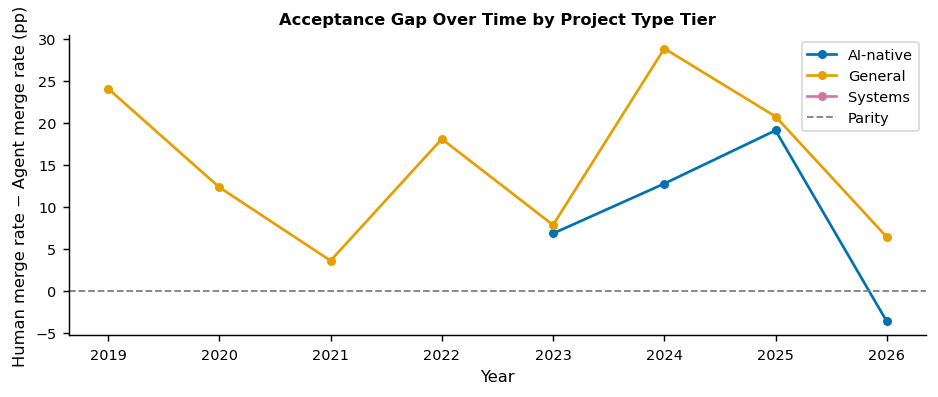

In [28]:
# Quality gap trend by tier (corrected classifier)
tier_gap_by_year = {}
for tier in ["AI-native", "General", "Systems"]:
    tier_repos = [r for r in repos if TIERS.get(r) == tier]
    tier_gap_by_year[tier] = {}
    for yr in all_years:
        gaps = []
        for repo in tier_repos:
            ag = [r for r in rows if r["repo"] == repo and r["origin_corrected"] == "agent"
                  and r["createdAt"] and r["createdAt"].year == yr]
            hg = [r for r in rows if r["repo"] == repo and r["origin_corrected"] == "human"
                  and r["createdAt"] and r["createdAt"].year == yr]
            if len(ag) >= 5 and len(hg) >= 5:
                a_mr = sum(1 for r in ag if r["is_merged"]) * 100 / len(ag)
                h_mr = sum(1 for r in hg if r["is_merged"]) * 100 / len(hg)
                gaps.append(h_mr - a_mr)
        if gaps:
            tier_gap_by_year[tier][yr] = sum(gaps) / len(gaps)

print("Tier-level gap by year (corrected classifier):")
for tier in ["AI-native", "General", "Systems"]:
    print(f"\n{tier}:")
    for yr in sorted(tier_gap_by_year[tier].keys()):
        print(f"  {yr}: {tier_gap_by_year[tier][yr]:+.1f}pp")

# IEEE double-column figure: 7.16 in wide, 9pt fonts
fig, ax = plt.subplots(figsize=(7.16, 3.0))
# Okabe-Ito colorblind-safe palette
colors = {"AI-native": "#0072B2", "General": "#E69F00", "Systems": "#CC79A7"}
for tier, color in colors.items():
    yrs = sorted(tier_gap_by_year[tier].keys())
    vals = [tier_gap_by_year[tier][y] for y in yrs]
    ax.plot(yrs, vals, marker="o", label=tier, color=color, linewidth=1.5, markersize=4)
ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="Parity")
ax.set_xlabel("Year", fontsize=9)
ax.set_ylabel("Human merge rate − Agent merge rate (pp)", fontsize=9)
ax.set_title("Acceptance Gap Over Time by Project Type Tier", fontweight="bold", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
ax.legend(fontsize=8, framealpha=0.7)
plt.tight_layout(pad=0.5)
plt.savefig("acceptance_gap_by_tier.pdf", dpi=300, bbox_inches="tight")
plt.savefig("acceptance_gap_by_tier.png", dpi=300, bbox_inches="tight")
print("Saved: acceptance_gap_by_tier.pdf  &  acceptance_gap_by_tier.png")
plt.show()

In [29]:
# ── L. Remaining data for the RQ2 closing paragraph and Section V.B ──

# langchain and TypeScript annual gaps (same pattern as the AutoGPT/vscode/ant-design pull)
target_names2 = ["langchain", "typescript"]
target_repos2 = [r for r in repos if any(n in r.lower() for n in target_names2)]

annual2 = defaultdict(lambda: defaultdict(lambda: {"agent": [0, 0], "human": [0, 0]}))
for r in rows:
    if r["repo"] not in target_repos2:
        continue
    dt = r["createdAt"]
    if dt is None:
        continue
    o = r["origin_corrected"]
    annual2[r["repo"]][dt.year][o][1] += 1
    if r["is_merged"]:
        annual2[r["repo"]][dt.year][o][0] += 1

print("=" * 70)
print("ANNUAL MERGE RATES: langchain, TypeScript (corrected)")
print("=" * 70)
for repo in target_repos2:
    print(f"\n{repo}")
    for year in sorted(annual2[repo].keys()):
        a_m, a_t = annual2[repo][year]["agent"]
        h_m, h_t = annual2[repo][year]["human"]
        a_rate = a_m / a_t * 100 if a_t else float("nan")
        h_rate = h_m / h_t * 100 if h_t else float("nan")
        if a_t >= 5 and h_t >= 5:
            print(f"  {year}: agent n={a_t:4d} rate={a_rate:5.1f}%   human n={h_t:5d} rate={h_rate:5.1f}%   gap={h_rate - a_rate:+5.1f}")
        else:
            print(f"  {year}: agent n={a_t:4d} rate={a_rate:5.1f}%   human n={h_t:5d} rate={h_rate:5.1f}%   (n<5, gap not meaningful)")

# scrcpy: confirm no year meets the n>=5 threshold under corrected classification
scrcpy_key = [r for r in repos if "scrcpy" in r.lower()][0]
print(f"\n{'=' * 70}\nscrcpy corrected agent PRs by year (confirming exclusion)\n{'=' * 70}")
scrcpy_by_year = defaultdict(int)
for r in rows:
    if r["repo"] == scrcpy_key and r["origin_corrected"] == "agent" and r["createdAt"]:
        scrcpy_by_year[r["createdAt"].year] += 1
for y in sorted(scrcpy_by_year):
    print(f"  {y}: {scrcpy_by_year[y]} agent PRs")

# Aggregate PR lifetime, overall and per-repo, corrected classification
agent_rows_c = [r for r in rows if r["origin_corrected"] == "agent" and r.get("lifetime_hours") is not None]
human_rows_c = [r for r in rows if r["origin_corrected"] == "human" and r.get("lifetime_hours") is not None]
agent_med = np.median([r["lifetime_hours"] for r in agent_rows_c])
human_med = np.median([r["lifetime_hours"] for r in human_rows_c])

print(f"\n{'=' * 70}\nAGGREGATE PR LIFETIME (median hours, corrected)\n{'=' * 70}")
print(f"Agent: {agent_med:.1f}h  (n={len(agent_rows_c):,})")
print(f"Human: {human_med:.1f}h  (n={len(human_rows_c):,})")

from scipy.stats import mannwhitneyu
print(f"\n{'Repo':<20} {'AgentMed':>10} {'HumanMed':>10} {'Direction':>12} {'p-value':>10}")
for repo in repos:
    a = [r["lifetime_hours"] for r in agent_rows_c if r["repo"] == repo]
    h = [r["lifetime_hours"] for r in human_rows_c if r["repo"] == repo]
    if len(a) < 5 or len(h) < 5:
        print(f"{repo.split('/')[1]:<20} {'--':>10} {'--':>10} {'(n<5)':>12}")
        continue
    a_med, h_med = np.median(a), np.median(h)
    direction = "agent longer" if a_med > h_med else "human longer"
    try:
        _, p = mannwhitneyu(a, h)
    except Exception:
        p = float("nan")
    print(f"{repo.split('/')[1]:<20} {a_med:>9.1f}h {h_med:>9.1f}h {direction:>12} {p:>10.6f}")

ANNUAL MERGE RATES: langchain, TypeScript (corrected)

langchain-ai/langchain
  2022: agent n=   2 rate=100.0%   human n=  794 rate= 87.7%   (n<5, gap not meaningful)
  2023: agent n=   6 rate= 66.7%   human n= 8415 rate= 78.1%   gap=+11.4
  2024: agent n=   5 rate= 20.0%   human n= 7538 rate= 78.5%   gap=+58.5
  2025: agent n= 116 rate= 49.1%   human n= 3702 rate= 74.4%   gap=+25.3
  2026: agent n= 585 rate= 56.6%   human n= 1809 rate= 39.6%   gap=-17.0

microsoft/TypeScript
  2014: agent n=   0 rate=  nan%   human n=  885 rate= 85.8%   (n<5, gap not meaningful)
  2015: agent n=   0 rate=  nan%   human n= 1352 rate= 83.4%   (n<5, gap not meaningful)
  2016: agent n=   0 rate=  nan%   human n= 1792 rate= 85.9%   (n<5, gap not meaningful)
  2017: agent n=   0 rate=  nan%   human n= 2123 rate= 85.9%   (n<5, gap not meaningful)
  2018: agent n=   3 rate= 66.7%   human n= 2955 rate= 85.2%   (n<5, gap not meaningful)
  2019: agent n=   7 rate= 57.1%   human n= 1779 rate= 70.3%   gap=+13.1
 

In [30]:
# ── M2. RQ2 mixed-effects model, revised for convergence ──
import statsmodels.api as sm

df_rq2 = pd.DataFrame([
    {"repo": r["repo"], "merged": int(r["is_merged"]), "origin": r["origin_corrected"],
     "year": r["createdAt"].year}
    for r in rows if r["createdAt"] is not None
])
df_rq2["agent"] = (df_rq2["origin"] == "agent").astype(int)
df_rq2["year_z"] = (df_rq2["year"] - df_rq2["year"].mean()) / df_rq2["year"].std()

print("=" * 70)
print("Step 1: agent only, independence structure (sanity check)")
print("=" * 70)
m1 = smf.gee("merged ~ agent", groups="repo", data=df_rq2,
             family=sm.families.Binomial(), cov_struct=sm.cov_struct.Independence())
r1 = m1.fit(maxiter=200)
print(r1.summary())

print("\n" + "=" * 70)
print("Step 2: agent only, exchangeable structure")
print("=" * 70)
m2 = smf.gee("merged ~ agent", groups="repo", data=df_rq2,
             family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable())
r2 = m2.fit(maxiter=200)
print(r2.summary())

print("\n" + "=" * 70)
print("Step 3: agent + year (no interaction), exchangeable structure")
print("=" * 70)
m3 = smf.gee("merged ~ agent + year_z", groups="repo", data=df_rq2,
             family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable())
r3 = m3.fit(maxiter=200)
print(r3.summary())

print("\n" + "=" * 70)
print("Step 4: agent * year interaction, exchangeable structure")
print("=" * 70)
m4 = smf.gee("merged ~ agent * year_z", groups="repo", data=df_rq2,
             family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable())
r4 = m4.fit(maxiter=200)
print(r4.summary())

Step 1: agent only, independence structure (sanity check)
                               GEE Regression Results                              
Dep. Variable:                      merged   No. Observations:               198739
Model:                                 GEE   No. clusters:                       10
Method:                        Generalized   Min. cluster size:                 868
                      Estimating Equations   Max. cluster size:               58067
Family:                           Binomial   Mean cluster size:             19873.9
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Fri, 25 Sep 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         01:00:49
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0653      0

In [ ]:
sample_fp = sorted(glob.glob(os.path.join(DATA_DIR, "*.json")))[0]
with open(sample_fp, "r", encoding="utf-8") as f:
    sample_d = json.load(f)

print("File:", sample_fp)
print("\nTop-level keys:", list(sample_d.keys()))
print("\nrepository sub-keys:", list(sample_d.get("repository", {}).keys()))
print("\nrepository field values (non-PR-list):")
for k, v in sample_d.get("repository", {}).items():
    if k != "pullRequests":
        print(f"  {k}: {v}")

# Find a PR that has at least one PullRequestReview event, and show its raw shape
prs = sample_d.get("repository", {}).get("pullRequests", {}).get("nodes", [])
for pr in prs:
    review_items = [item for item in pr.get("timelineItems", {}).get("nodes", [])
                     if item.get("__typename") == "PullRequestReview"]
    if review_items:
        print("\nSample PullRequestReview timeline item:")
        print(json.dumps(review_items[0], indent=2)[:1000])
        break
else:
    print("\nNo PullRequestReview items found in the first file's PRs -- check spelling/typename.")

print("\nrepos list (first 3):", repos[:3])

File: data\Genymobile+scrcpy.json

Top-level keys: ['repository']

repository sub-keys: ['nameWithOwner', 'pullRequests']

repository field values (non-PR-list):
  nameWithOwner: Genymobile/scrcpy

Sample PullRequestReview timeline item:
{
  "__typename": "PullRequestReview",
  "submittedAt": "2026-05-10T15:54:51Z"
}

repos list (first 3): ['Genymobile/scrcpy', 'Significant-Gravitas/AutoGPT', 'TheAlgorithms/Python']


In [ ]:
total_reviews = 0
reviews_with_actor = 0
reviews_with_author = 0
sample_keys_seen = set()

for fp in sorted(glob.glob(os.path.join(DATA_DIR, "*.json"))):
    if fp.lower().endswith("desktop.ini"):
        continue
    with open(fp, "r", encoding="utf-8") as f:
        d = json.load(f)
    for pr in d.get("repository", {}).get("pullRequests", {}).get("nodes", []):
        for item in pr.get("timelineItems", {}).get("nodes", []):
            if item.get("__typename") != "PullRequestReview":
                continue
            total_reviews += 1
            sample_keys_seen.update(item.keys())
            if item.get("actor"):
                reviews_with_actor += 1
            if item.get("author"):
                reviews_with_author += 1

print(f"Total PullRequestReview events: {total_reviews:,}")
print(f"With a non-null 'actor' field: {reviews_with_actor:,}")
print(f"With a non-null 'author' field: {reviews_with_author:,}")
print(f"\nAll keys ever seen on a PullRequestReview item: {sorted(sample_keys_seen)}")

Total PullRequestReview events: 266,257
With a non-null 'actor' field: 0
With a non-null 'author' field: 0

All keys ever seen on a PullRequestReview item: ['__typename', 'submittedAt']
